# Fitting kinetic models directly on headspace ngas(t) _ ONLY pressure data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D
from matplotlib import rcParams
from scipy.signal import savgol_filter, find_peaks, correlate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit, minimize
from sklearn.metrics import mean_squared_error, r2_score
import pywt
from datetime import datetime
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.stats import linregress
from scipy.stats import pearsonr
from scipy.constants import R
from matplotlib.patheffects import withStroke
from scipy.ndimage import gaussian_filter1d, uniform_filter1d
import seaborn as sns


In [15]:
# === Plotting ===
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
legend_font = 13
dpi = 900

# Define custom colors
colors = {
    "raw": "#009F82",        # Teal blue
    "drift": "#D95F02",      # Classic orange
    "corrected": "#7570B3",  # Soft purple (keeps consistency)
    "sg": "#E7298A",         # Magenta pink for SG-filtered

    "dwt": '#2c7bb6',        # Dark Blue
    "first": '#e66101',      # Warm Orange – mid-performing
    "logi": '#d95f02',       # Deep Red
    "gomp": "#009F82",       # Teal blue

    "dual": "#999999"        # Gray (less prominent)
}

def format_ax(ax, xlabel="Elapsed time (h)", ylabel="Pressure (kPa)"):
    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=15)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
    ax.minorticks_on()
    ax.grid(axis='y', linestyle='--', alpha=0.8)


# Half life calculation :

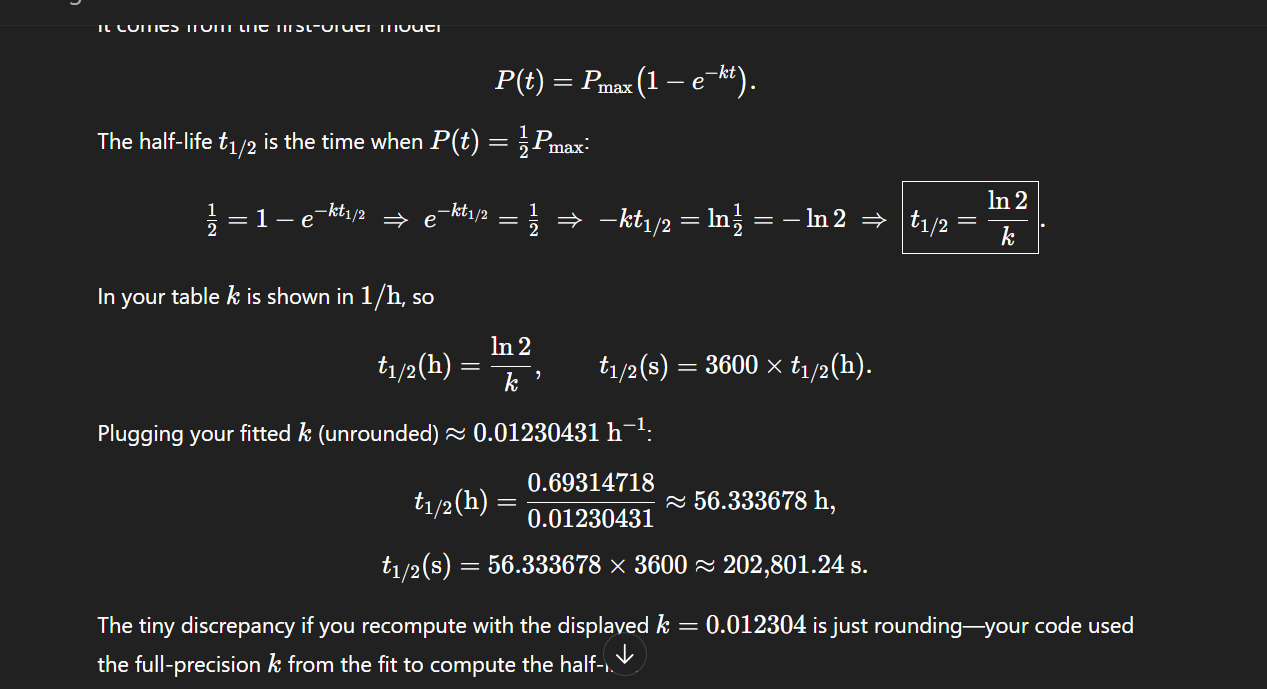

# more info about half life

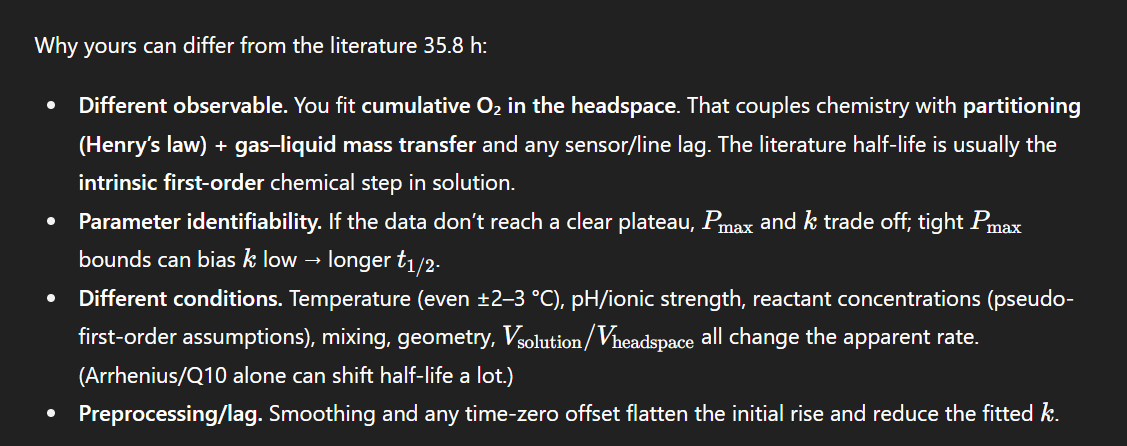

# M1 - 2.5mM  @ RT

## First order

,Model,P_max (µmol),k (1/h),Half-Life (s),Half-Life (h),RMSE (µmol),R²,AIC,BIC
0,First-order,14.651116,0.012304,202801.241402,56.333678,1.104095,0.933834,178131.508316,178154.927278


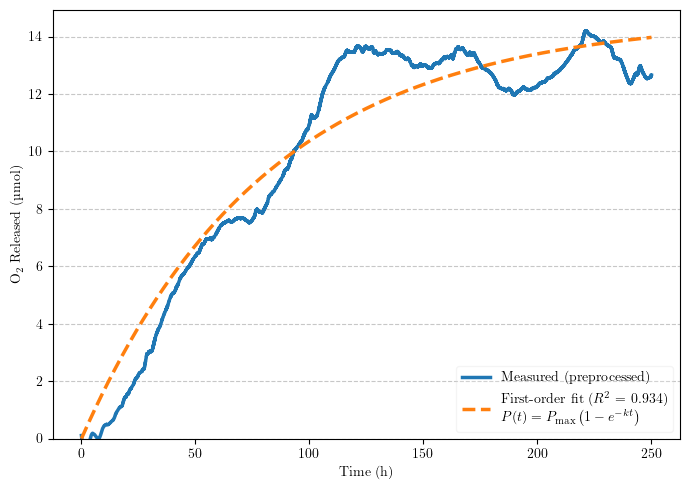

In [17]:

# ---- Load your preprocessed CSV ----
m1_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\O2_RT_released_multi_volumes.csv"
df_m1 = pd.read_csv(m1_csv)
df_m1.columns = [c.strip() for c in df_m1.columns]

# Replace these with the series/column you want to fit
ngas_m1 = df_m1["O2 Released (µmol) - Vg=4.0mL"].values
time_m1 = df_m1["Time (s)"].values

# --- Clean: drop NaNs/Infs and ensure strictly increasing time (if needed) ---
mask = np.isfinite(time_m1) & np.isfinite(ngas_m1)
t = np.asarray(time_m1[mask], dtype=float)
y = np.asarray(ngas_m1[mask], dtype=float)

# If times are not strictly increasing, sort them (and y accordingly)
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y = t[order], y[order]

# Optionally, shift time to start at 0 for numerical stability (doesn't change k)
t0 = t.min()
t = t - t0

# --- First-order model ---
def first_order_model(t, P_max, k):
    # P(t) = P_max * (1 - exp(-k t))
    return P_max * (1.0 - np.exp(-k * t))

# --- Fit: robust initial guesses + nonnegative bounds ---
Pmax0 = float(np.nanmax(y))
dt = max(t.max() - t.min(), 1.0)  # seconds span; guard against zero

# simplest: constant small positive guess (1/s)
k0 = 1e-6

# k0 = max(k0, 1e-9)
#lower and upper bounds are [P_max ≥ 0, k ≥ 0]
lower_bounds = [0.8 * Pmax0, 0.0]               
upper_bounds = [1.2 * Pmax0, np.inf]

popt, pcov = curve_fit(
    first_order_model, t, y,
    p0=[Pmax0, k0],
    bounds=(lower_bounds, upper_bounds),
    maxfev=200000
)

# popt, pcov = curve_fit(
#     first_order_model, t, y,
#     p0=[Pmax0 if np.isfinite(Pmax0) and Pmax0 > 0 else (y[-1] if len(y) else 1.0), k0],
#     bounds=([0.0, 0.0], [np.inf, np.inf]),
#     maxfev=20000
# )

P_max_fit, k_fit = popt
y_fit = first_order_model(t, *popt)

# --- Metrics (first-order only) ---
def aic(n, rss, k_params):
    return n * np.log(rss / n) + 2 * k_params

def bic(n, rss, k_params):
    return n * np.log(rss / n) + k_params * np.log(n)

n = len(y)
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
aic_val = aic(n, rss, 2)  # params: P_max, k
bic_val = bic(n, rss, 2)
t_half_h = np.log(2.0) / k_fit
t_half_s = t_half_h * 3600.0

# --- Show metrics ---
metrics = pd.DataFrame({
    "Model": ["First-order"],
    "P_max (µmol)": [P_max_fit],
    "k (1/h)": [k_fit],
    "Half-Life (s)": [t_half_s],
    "Half-Life (h)": [t_half_h],
    "RMSE (µmol)": [rmse],
    "R²": [r2],
    "AIC": [aic_val],
    "BIC": [bic_val],
})
display(metrics.round(6))

# --- Plot (Plot #3 analog: data + first-order fit only) ---
plt.figure(figsize=(7, 5))
plt.plot(t + t0, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t + t0, y_fit, "--", lw=2.5,
         label=fr"First-order fit ($R^2$ = {r2:.3f})" + "\n" + r"$P(t)=P_{\max}\left(1-e^{-kt}\right)$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.xlim()
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


In [5]:
# to check if there k bound is stuck in the bounds

eps = 1e-12
hit_lower = np.isclose(k_fit, lower_bounds[1], atol=eps, rtol=0)
hit_upper = np.isfinite(upper_bounds[1]) and np.isclose(k_fit, upper_bounds[1], atol=eps, rtol=0)
print("k at lower bound?", hit_lower, " | k at upper bound?", hit_upper)


k at lower bound? False  | k at upper bound? False


# Exploring other metrics

In [8]:
# === Extra metrics & diagnostics (drop-in block) ===
import numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr, spearmanr, t as student_t

# optional tests (autocorrelation & heteroscedasticity)
try:
    from statsmodels.stats.stattools import durbin_watson
    from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
    import statsmodels.api as sm
    _has_sm = True
except Exception:
    _has_sm = False

res = y - y_fit
n = y.size
p = 2  # number of parameters: P_max, k

# Sums of squares
SSE = float(np.sum(res**2))
SST = float(np.sum((y - y.mean())**2))
SSR = float(np.sum((y_fit - y.mean())**2))

# Error metrics
RMSE = float(np.sqrt(SSE / n))
MAE = float(mean_absolute_error(y, y_fit))
mask_pos = y != 0
MAPE = float(100.0 * np.mean(np.abs((y[mask_pos] - y_fit[mask_pos]) / y[mask_pos]))) if mask_pos.any() else np.nan
MPE  = float(100.0 * np.mean(((y_fit[mask_pos] - y[mask_pos]) / y[mask_pos]))) if mask_pos.any() else np.nan
sMAPE = float(100.0 * np.mean(2.0 * np.abs(y - y_fit) / (np.abs(y) + np.abs(y_fit) + 1e-12)))
MaxAE = float(np.max(np.abs(res)))
NRMSE_range = float(RMSE / (y.max() - y.min() + 1e-12))
NRMSE_mean  = float(RMSE / (np.mean(y) + 1e-12))

# Fit quality
R2 = 1.0 - SSE / SST if SST > 0 else np.nan
adj_R2 = 1.0 - (1.0 - R2) * (n - 1) / max(n - p - 1, 1)

# Information criteria (+ small-sample AICc)
AIC = n * np.log(SSE / n + 1e-300) + 2 * p
BIC = n * np.log(SSE / n + 1e-300) + p * np.log(max(n, 1))
AICc = np.nan if n <= (p + 1) else AIC + (2 * p * (p + 1)) / (n - p - 1)

# Correlations between y and fitted y
pearson_r, pearson_p = pearsonr(y, y_fit)
spearman_rho, spearman_p = spearmanr(y, y_fit)

# Parameter SEs & 95% CI from covariance (pcov)
param_table = None
if isinstance(pcov, np.ndarray) and pcov.shape == (p, p):
    se = np.sqrt(np.diag(pcov))
    dof = max(n - p, 1)
    tcrit = float(student_t.ppf(0.975, dof))
    params = np.array([P_max_fit, k_fit], dtype=float)
    ci_low = params - tcrit * se
    ci_high = params + tcrit * se
    param_table = pd.DataFrame({
        "param": ["P_max (µmol)", "k (1/unit_time)"],
        "estimate": params,
        "std_err": se,
        "ci95_low": ci_low,
        "ci95_high": ci_high,
    })

# Residual diagnostics (optional; requires statsmodels)
dw = np.nan
bp_pvalue = np.nan
lb_pvalue_10 = np.nan
if _has_sm:
    dw = float(durbin_watson(res))  # ~2 means little autocorrelation
    exog = sm.add_constant(np.column_stack([y_fit, t]))
    lm_stat, bp_pvalue, f_stat, f_pvalue = het_breuschpagan(res, exog)  # use p-value
    lb = acorr_ljungbox(res, lags=[10], return_df=True)
    lb_pvalue_10 = float(lb["lb_pvalue"].iloc[0])

# Half-life (if k is in 1/s → seconds; convert to hours)
t_half_s = float(np.log(2.0) / k_fit)
t_half_h = t_half_s / 3600.0

more_metrics = pd.DataFrame({
    "n": [n],
    "SSE": [SSE],
    "SSR": [SSR],
    "SST": [SST],
    "RMSE": [RMSE],
    "MAE": [MAE],
    "MAPE (%)": [MAPE],
    "MPE (%)": [MPE],
    "sMAPE (%)": [sMAPE],
    "Max |Error|": [MaxAE],
    "NRMSE (range)": [NRMSE_range],
    "NRMSE (mean)": [NRMSE_mean],
    "R²": [R2],
    "Adj. R²": [adj_R2],
    "AIC": [AIC],
    "AICc": [AICc],
    "BIC": [BIC],
    "Pearson r": [pearson_r],
    "Pearson p": [pearson_p],
    "Spearman ρ": [spearman_rho],
    "Spearman p": [spearman_p],
    "Durbin–Watson": [dw],
    "Breusch–Pagan p": [bp_pvalue],
    "Ljung–Box p (lag=10)": [lb_pvalue_10],
    "t½ (s)": [t_half_s],
    "t½ (h)": [t_half_h],
})

display(more_metrics.round(6))
if param_table is not None:
    display(param_table.round(6))


,n,SSE,SSR,SST,RMSE,MAE,MAPE (%),MPE (%),sMAPE (%),Max |Error|,...,BIC,Pearson r,Pearson p,Spearman ρ,Spearman p,Durbin–Watson,Breusch–Pagan p,Ljung–Box p (lag=10),t½ (s),t½ (h)
0,899398,1.096389e+06,1.277036e+07,1.657036e+07,1.104095,0.940995,277.84592,30.170817,20.57838,2.366712,...,178154.927278,0.971589,0.0,0.777544,0.0,0.0,0.0,0.0,56.333678,0.015648


,param,estimate,std_err,ci95_low,ci95_high
0,P_max (µmol),14.651116,0.003660,14.643942,14.658289
1,k (1/unit_time),0.012304,0.000008,0.012288,0.012320


In [12]:
# === ML-friendly feature extractor (unit-aware, robust) ===
import numpy as np
import pandas as pd

def compute_ml_features(t, y, y_fit, P_max_fit, k_fit, time_unit='s'):
    """
    Parameters
    ----------
    t : array-like
        Time used in the fit (same units k is paired with).
    y : array-like
        Observed cumulative signal.
    y_fit : array-like
        Model fit to y at times t.
    P_max_fit : float
        Fitted plateau.
    k_fit : float
        Fitted rate constant (units are 1/<time_unit>).
    time_unit : {'s','h'}
        Unit of t (and thus of k). Set correctly!

    Returns
    -------
    pd.DataFrame with one row of ML features.
    """
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    y_fit = np.asarray(y_fit, float)
    n = len(y)
    assert n == len(t) == len(y_fit)

    # Unit helpers
    sec_per_unit = 1.0 if time_unit == 's' else 3600.0
    hours_per_unit = 1.0/3600.0 if time_unit == 's' else 1.0

    # Basic deltas
    dt = np.diff(t)
    dy = np.diff(y)

    # Residuals
    res = y - y_fit
    y_rng = max(y.max() - y.min(), 1e-12)
    y_mean = max(np.mean(y), 1e-12)
    Pmax_safe = max(P_max_fit, 1e-12)
    k_safe = max(k_fit, 1e-18)

    # Error metrics (normalized)
    rmse = np.sqrt(np.mean(res**2))
    mae = np.mean(np.abs(res))
    bias = np.mean(res)
    nrmse = rmse / y_rng
    mae_norm = mae / y_rng
    bias_norm = bias / y_rng

    # Residual structure
    res_center = res - res.mean()
    if res_center.std() > 0 and n > 2:
        lag1_autocorr = float(np.dot(res_center[1:], res_center[:-1]) / np.dot(res_center, res_center))
    else:
        lag1_autocorr = np.nan
    # Heteroscedasticity proxy: correlation between |res| and fitted level
    corr_absres_fit = np.corrcoef(np.abs(res), y_fit)[0,1] if np.std(np.abs(res))>0 and np.std(y_fit)>0 else np.nan
    # Shape of residuals
    res_std = np.std(res)
    res_skew = (np.mean(((res - res.mean())/res_std)**3) if res_std>0 else np.nan)
    res_kurt = (np.mean(((res - res.mean())/res_std)**4) - 3.0 if res_std>0 else np.nan)

    # Monotonicity violations (should be ~0 for cumulative curves)
    mono_violations = int(np.sum(dy < -1e-12))

    # Sampling characteristics
    median_dt = float(np.median(dt)) if n > 1 else np.nan
    samplerate_hz = (1.0 / (median_dt * sec_per_unit)) if np.isfinite(median_dt) and median_dt>0 else np.nan
    t_span_units = float(t.max() - t.min()) if n > 0 else np.nan
    t_span_h = t_span_units * hours_per_unit

    # Model-derived time constants and slopes
    tau_units = 1.0 / k_safe                   # same units as t
    t_half_units = np.log(2.0) / k_safe
    t10_units = -np.log(1-0.10) / k_safe
    t50_units = -np.log(1-0.50) / k_safe
    t90_units = -np.log(1-0.90) / k_safe
    # Convert to hours for convenience
    tau_h = tau_units * hours_per_unit
    t_half_h = t_half_units * hours_per_unit
    t10_h = t10_units * hours_per_unit
    t50_h = t50_units * hours_per_unit
    t90_h = t90_units * hours_per_unit

    # Initial slope (model) and data-based slopes
    s0_model_per_unit = P_max_fit * k_fit        # dP/dt at t=0 (units: µmol / <time_unit>)
    s0_model_per_h = s0_model_per_unit / hours_per_unit  # convert to per hour derivative

    # Robust empirical slopes: first 5% time vs last 5% time
    if n > 5:
        q = np.quantile(t, [0.0, 0.05, 0.95, 1.0])
        early_mask = (t >= q[0]) & (t <= q[1])
        late_mask  = (t >= q[2]) & (t <= q[3])
        # guard if masks tiny
        if early_mask.sum() >= 3 and late_mask.sum() >= 3:
            gy = np.gradient(y, t, edge_order=2)
            early_slope = float(np.median(gy[early_mask]))
            late_slope  = float(np.median(gy[late_mask]))
            slope_ratio = (early_slope / (abs(late_slope) + 1e-18))
        else:
            early_slope = late_slope = slope_ratio = np.nan
    else:
        early_slope = late_slope = slope_ratio = np.nan

    # Observed progress/plateau
    y_obs_max = float(y.max())
    plateau_fraction = float(y_obs_max / Pmax_safe)
    reached_90_flag = bool(y_obs_max >= 0.90 * P_max_fit)

    # Observed t10/t50/t90 by interpolation (using P_max_fit as target)
    def observed_tx(f):
        target = f * P_max_fit
        if (y[0] > target) or (y_obs_max < target):
            return np.nan
        return float(np.interp(target, y, t))
    t10_obs_units = observed_tx(0.10)
    t50_obs_units = observed_tx(0.50)
    t90_obs_units = observed_tx(0.90)
    t10_obs_h = t10_obs_units * hours_per_unit if np.isfinite(t10_obs_units) else np.nan
    t50_obs_h = t50_obs_units * hours_per_unit if np.isfinite(t50_obs_units) else np.nan
    t90_obs_h = t90_obs_units * hours_per_unit if np.isfinite(t90_obs_units) else np.nan

    # Normalized AUC of fractional completion over the window [t0, t_end]
    frac = np.clip(y / Pmax_safe, 0, 1)
    auc_norm = float(np.trapz(frac, t) / (t_span_units + 1e-18))  # dimensionless mean completion
    frac_fit = np.clip(y_fit / Pmax_safe, 0, 1)
    auc_fit_norm = float(np.trapz(frac_fit, t) / (t_span_units + 1e-18))

    # Early vs late residual variance (heteroscedasticity cue)
    if n > 10:
        res_early_std = float(np.std(res[: n//10]))
        res_late_std  = float(np.std(res[- n//10:]))
        res_std_ratio = res_late_std / (res_early_std + 1e-18)
    else:
        res_early_std = res_late_std = res_std_ratio = np.nan

    # Package features
    feats = dict(
        # identifiers/basic
        n_points=n,
        t_span_h=t_span_h,
        samplerate_hz=samplerate_hz,

        # physics/time constants
        P_max=P_max_fit,
        k=k_fit,
        tau_h=tau_h,
        t_half_h=t_half_h,
        t10_h=t10_h,
        t50_h=t50_h,
        t90_h=t90_h,
        s0_model_per_h=s0_model_per_h,

        # progress/plateau
        y_obs_max=y_obs_max,
        plateau_fraction=plateau_fraction,
        reached_90_flag=int(reached_90_flag),
        t10_obs_h=t10_obs_h,
        t50_obs_h=t50_obs_h,
        t90_obs_h=t90_obs_h,

        # fit quality (scale-free)
        NRMSE=nrmse,
        MAE_norm=mae_norm,
        bias_norm=bias_norm,

        # dynamics shape
        early_slope=early_slope * hours_per_unit,   # convert to per hour
        late_slope=late_slope * hours_per_unit,
        slope_ratio=slope_ratio,
        auc_norm=auc_norm,
        auc_fit_norm=auc_fit_norm,

        # residual structure
        lag1_autocorr=lag1_autocorr,
        corr_absres_fit=corr_absres_fit,
        res_skew=res_skew,
        res_kurt=res_kurt,

        # heteroscedasticity cue
        res_early_std=res_early_std,
        res_late_std=res_late_std,
        res_std_ratio=res_std_ratio,

        # sanity
        monotonicity_violations=mono_violations,
    )
    return pd.DataFrame([feats])

# ---- Example usage (set the correct time unit!) ----
# TIME_UNIT = 's'  # if your t is in seconds
TIME_UNIT = 'h'    # if your t is in hours
ml_features = compute_ml_features(t, y, y_fit, P_max_fit, k_fit, time_unit=TIME_UNIT)
display(ml_features.round(6))


C:\Users\chand\AppData\Local\Temp\ipykernel_19768\137176954.py:130: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_norm = float(np.trapz(frac, t) / (t_span_units + 1e-18))  # dimensionless mean completion
C:\Users\chand\AppData\Local\Temp\ipykernel_19768\137176954.py:132: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_fit_norm = float(np.trapz(frac_fit, t) / (t_span_units + 1e-18))


,n_points,t_span_h,samplerate_hz,P_max,k,tau_h,t_half_h,t10_h,t50_h,t90_h,...,auc_norm,auc_fit_norm,lag1_autocorr,corr_absres_fit,res_skew,res_kurt,res_early_std,res_late_std,res_std_ratio,monotonicity_violations
0,899398,249.832778,0.999999,14.651116,0.012304,81.272318,56.333678,8.562893,56.333678,187.136428,...,0.679549,0.689734,0.999999,-0.144641,0.668274,-0.506916,0.462756,0.588247,1.271182,409706


In [7]:
# from scipy.stats import t as t_dist, shapiro, normaltest
# import numpy as np
# import pandas as pd

# # --- Basic sizes ---
# p = 2  # number of parameters in the first-order model: [P_max, k]
# dof = max(n - p, 1)

# # --- Extra error metrics ---
# res = y - y_fit
# abs_err = np.abs(res)

# mae   = float(abs_err.mean())
# medae = float(np.median(abs_err))
# maxae = float(abs_err.max())
# p95ae = float(np.percentile(abs_err, 95))

# # Guard against division by zero in MAPE; sMAPE is safer
# with np.errstate(divide='ignore', invalid='ignore'):
#     mape = float(np.nanmean(np.abs(res / np.where(y != 0, y, np.nan))) * 100.0)
# smape = float(100.0 * np.mean(2.0 * abs_err / (np.abs(y) + np.abs(y_fit) + 1e-12)))

# yrange = float(np.ptp(y))
# ymean  = float(np.mean(y))
# nrmse_range = float(rmse / yrange) if yrange > 0 else np.nan
# nrmse_mean  = float(rmse / ymean)  if ymean  != 0 else np.nan

# # --- Adjusted R² and extra information criteria ---
# adj_r2 = 1.0 - (1.0 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else np.nan
# aicc   = aic_val + (2 * p * (p + 1)) / (n - p - 1) if n > p + 1 else np.nan
# hqc    = n * np.log(rss / n) + 2 * p * np.log(np.log(n))

# # --- Residual diagnostics ---
# # Durbin–Watson for autocorrelation in residuals
# dw = float(np.sum(np.diff(res)**2) / np.sum(res**2)) if np.sum(res**2) > 0 else np.nan

# # Normality tests (use both; Shapiro better for n<=5000, K² for larger n)
# if 3 <= n <= 5000:
#     sw_stat, sw_p = shapiro(res)
# else:
#     sw_stat, sw_p = (np.nan, np.nan)

# k2_stat, k2_p = normaltest(res) if n >= 20 else (np.nan, np.nan)

# # Optional Ljung–Box Q test at lag 10 (requires statsmodels)
# try:
#     from statsmodels.stats.diagnostic import acorr_ljungbox
#     lb = acorr_ljungbox(res, lags=[10], return_df=True)
#     lb_q, lb_p = float(lb['lb_stat'].iloc[0]), float(lb['lb_pvalue'].iloc[0])
# except Exception:
#     lb_q, lb_p = np.nan, np.nan

# # --- Parameter uncertainty from covariance (pcov) ---
# param_names = ['P_max', 'k']
# se = np.sqrt(np.diag(pcov)) if pcov is not None else np.array([np.nan]*p)
# tcrit = t_dist.ppf(0.975, df=n - p) if n > p else np.nan
# ci_low  = popt - tcrit * se if np.isfinite(tcrit) else np.array([np.nan]*p)
# ci_high = popt + tcrit * se if np.isfinite(tcrit) else np.array([np.nan]*p)

# # Correlation matrix between parameters
# with np.errstate(invalid='ignore', divide='ignore'):
#     corr = pcov / np.outer(se, se) if pcov is not None else np.full((p, p), np.nan)

# param_table = pd.DataFrame({
#     'Parameter': param_names,
#     'Estimate': popt,
#     'Std. Error': se,
#     'CI 2.5%': ci_low,
#     'CI 97.5%': ci_high,
# })

# extra_metrics = pd.DataFrame({
#     "MAE (µmol)": [mae],
#     "MedAE (µmol)": [medae],
#     "MaxAE (µmol)": [maxae],
#     "P95 AE (µmol)": [p95ae],
#     "MAPE (%)": [mape],
#     "sMAPE (%)": [smape],
#     "NRMSE / range": [nrmse_range],
#     "NRMSE / mean": [nrmse_mean],
#     "Adjusted R²": [adj_r2],
#     "AICc": [aicc],
#     "HQC": [hqc],
#     "Durbin–Watson": [dw],
#     "Shapiro–Wilk p": [sw_p],
#     "D'Agostino K² p": [k2_p],
#     "Ljung–Box Q(10)": [lb_q],
#     "Ljung–Box p(10)": [lb_p],
# }).round(6)

# display(extra_metrics)
# display(param_table.round(6))

# # (optional) show parameter correlation matrix
# try:
#     corr_df = pd.DataFrame(corr, index=param_names, columns=param_names)
#     print("\nParameter correlation matrix:\n", corr_df.round(3).to_string())
# except Exception:
#     pass

# #(optional) compare to literature half-life if you want a quick check:
# t_half_lit_h = 35.8
# print(f"\nHalf-life difference vs literature: {t_half_h:.3f} h  vs  {t_half_lit_h:.3f} h "
#       f"(Δ = {t_half_h - t_half_lit_h:.3f} h, {100*(t_half_h/t_half_lit_h - 1):.1f}%)")


# Logistic

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC
0,Logistic (bounded),13.182843,0.043771,59.024291,0.770846,0.967748,-468159.844205,-468124.715762


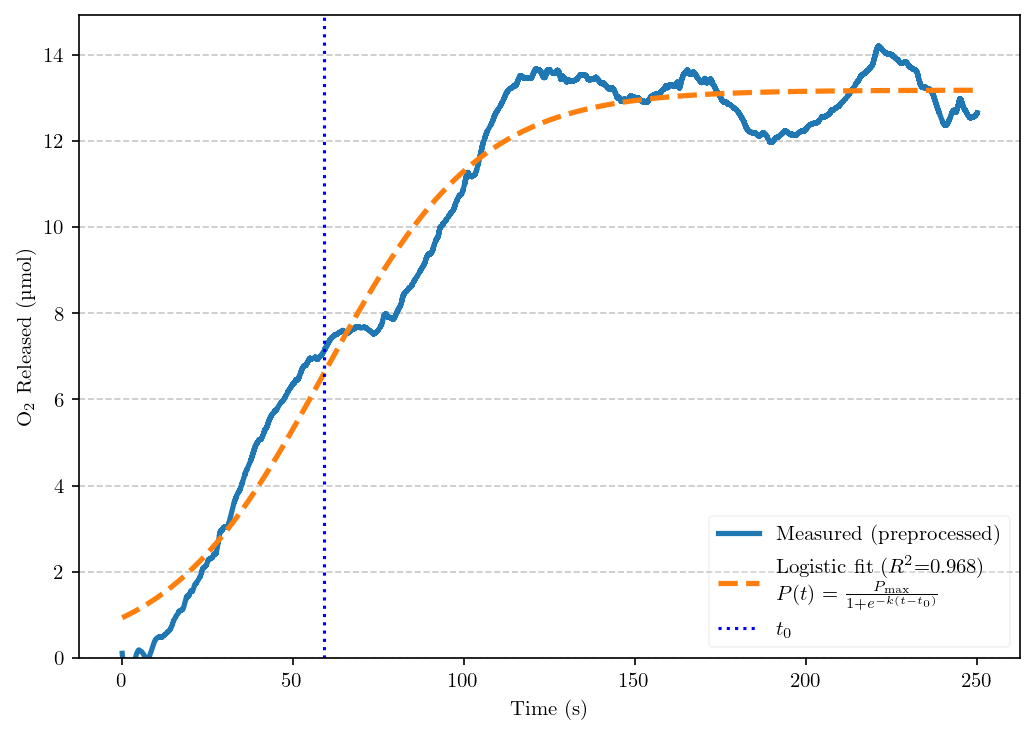

In [49]:

# ---- Load your preprocessed CSV ----
mlogi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\O2_RT_released_multi_volumes.csv"
df_mlogi = pd.read_csv(mlogi_csv)
df_mlogi.columns = [c.strip() for c in df_mlogi.columns]

# Replace these with the series/column you want to fit
ngas_mlogi = df_mlogi["O2 Released (µmol) - Vg=4.0mL"].values
time_mlogi = df_mlogi["Time (s)"].values

# --- Clean NaNs/Infs ---
mask = np.isfinite(time_mlogi) & np.isfinite(ngas_mlogi)
t = np.asarray(time_mlogi[mask], dtype=float)
y = np.asarray(ngas_mlogi[mask], dtype=float)

# --- Logistic model ---
def logistic_model(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))

# --- Fit function with bounds from table ---
def fit_logistic_model(time, signal):
    P_max = np.max(signal)
    # initial guess for t0 = time at ~half max
    P0_init = time[np.argmin(np.abs(signal - P_max / 2.0))]
    k_init = 1.0 / (time[-1] - time[0] + 1e-9)  # avoid div/0
    
    # bounds according to table:
    # t0: [0.8 * P0_init, 1.2 * P0_init]
    # k: [0, 1]
    # P_max: [0.8 * P_max, 1.2 * P_max]
    bounds = [
        (0.8 * P0_init, 1.2 * P0_init),
        (0.0, 1.0),
        (0.8 * P_max, 1.2 * P_max)
    ]
    
    res = minimize(
        lambda p: mean_squared_error(signal, logistic_model(time, *p)),
        [P0_init, k_init, P_max],
        bounds=bounds
    )
    popt = res.x
    fit = logistic_model(time, *popt)
    return popt, fit

# --- Run fit ---
popt, y_fit = fit_logistic_model(t, y)
t0_fit, k_fit, Pmax_fit = popt

# --- Metrics ---
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 3
bic = n * np.log(rss / n) + 3 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Logistic (bounded)"],
    "P_max (µmol)": [Pmax_fit],
    "k (1/h)": [k_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic]
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic fit ($R^2$={r2:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit, linestyle=":", color="blue", label=r"$t_0$")
plt.xlabel("Time (s)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# Gompertz

### Using unrestricted bounds

,Model,P_max (µmol),k (1/h),λ (lag),RMSE,R²,AIC,BIC
0,Gompertz,13.329875,0.030748,1.364407,0.755083,0.969054,-505324.524451,-505289.396008


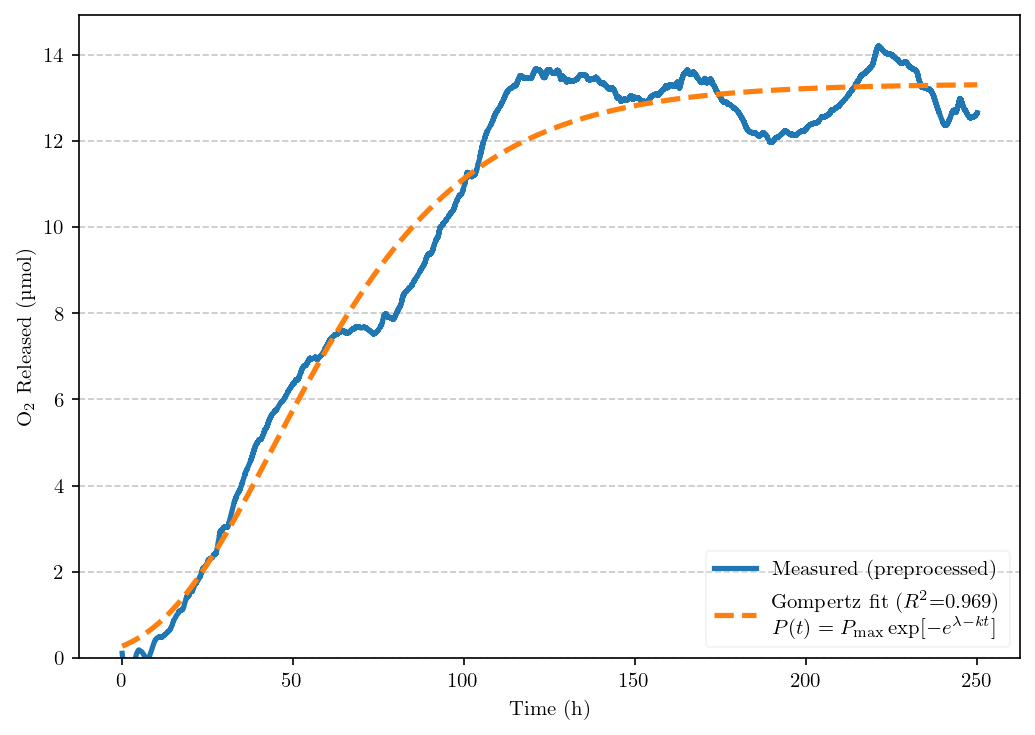

In [69]:

m1gom_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\O2_RT_released_multi_volumes.csv"
df_m1gom = pd.read_csv(m1gom_csv)
df_m1gom.columns = [c.strip() for c in df_m1gom.columns]

ngas_m1gom = df_m1gom["O2 Released (µmol) - Vg=4.0mL"].values
time_m1gom = df_m1gom["Time (s)"].values 

# Clean 
mask = np.isfinite(time_m1gom) & np.isfinite(ngas_m1gom)
t_m1gom = np.asarray(time_m1gom[mask], dtype=float)
y_m1gom = np.asarray(ngas_m1gom[mask], dtype=float)


def gompertz_model_m1gom(t, P_max, k, lam):
    return P_max * np.exp(-np.exp(lam - k * t))


Pmax0_m1gom = np.max(y_m1gom)
k0_m1gom = 1.0 / (t_m1gom[-1] - t_m1gom[0])
lam0_m1gom = np.log(np.log(Pmax0_m1gom / max(y_m1gom[0], 1e-9) + 1))  # heuristic guess
#++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
p0_m1gom = [Pmax0_m1gom, k0_m1gom, lam0_m1gom]


popt_m1gom, pcov_m1gom = curve_fit(
    gompertz_model_m1gom, t_m1gom, y_m1gom, p0=p0_m1gom,
    bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]),   #[lower bounds] [upper bounds] Pmax >=0, k>=0, lambda is unrestricted. more tuning is required in this case
    maxfev=20000  #allowing more iterations so optimizer doesnt die easily
)
Pmax_fit_m1gom, k_fit_m1gom, lam_fit_m1gom = popt_m1gom
y_fit_m1gom = gompertz_model_m1gom(t_m1gom, *popt_m1gom)



#metrics calculation
rss_m1gom = np.sum((y_m1gom - y_fit_m1gom) ** 2)
rmse_m1gom = np.sqrt(mean_squared_error(y_m1gom, y_fit_m1gom))
r2_m1gom = r2_score(y_m1gom, y_fit_m1gom)
n_m1gom = len(y_m1gom)
aic_m1gom = n_m1gom * np.log(rss_m1gom / n_m1gom) + 2 * 3
bic_m1gom = n_m1gom * np.log(rss_m1gom / n_m1gom) + 3 * np.log(n_m1gom)

metrics_m1gom = pd.DataFrame({
    "Model": ["Gompertz"],
    "P_max (µmol)": [Pmax_fit_m1gom],
    "k (1/h)": [k_fit_m1gom],
    "λ (lag)": [lam_fit_m1gom],
    "RMSE": [rmse_m1gom],
    "R²": [r2_m1gom],
    "AIC": [aic_m1gom],
    "BIC": [bic_m1gom]
})
display(metrics_m1gom.round(6))


plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t_m1gom, y_m1gom, label="Measured (preprocessed)", lw=2.5)
plt.plot(t_m1gom, y_fit_m1gom, "--", lw=2.5,
         label=fr"Gompertz fit ($R^2$={r2_m1gom:.3f})" + "\n" + r"$P(t)=P_{\max}\exp[-e^{\lambda - kt}]$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# Gompertz
### Using the same bounds as logistic

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC
0,"Gompertz (time-located, bounded)",13.44273,0.030763,47.201608,0.777947,0.967151,-451665.904626,-451630.776184


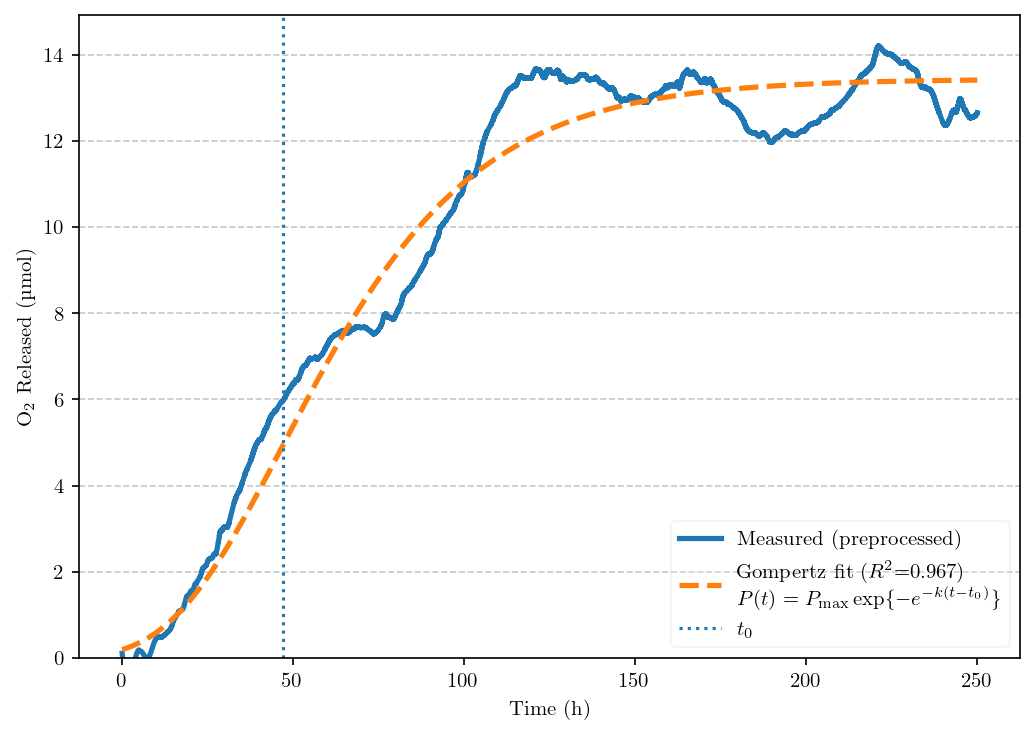

In [68]:


# ---- Load CSV ----
m11gom_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\O2_RT_released_multi_volumes.csv"
df_m11gom = pd.read_csv(m11gom_csv)
df_m11gom.columns = [c.strip() for c in df_m11gom.columns]

ngas_m11gom = df_m11gom["O2 Released (µmol) - Vg=4.0mL"].values
time_m11gom = df_m11gom["Time (s)"].values  # assume seconds here

# ---- Clean ----
mask = np.isfinite(time_m11gom) & np.isfinite(ngas_m11gom)
t_m11gom = np.asarray(time_m11gom[mask], dtype=float)
y_m11gom = np.asarray(ngas_m11gom[mask], dtype=float)

# Ensure increasing time
if np.any(np.diff(t_m11gom) <= 0):
    order = np.argsort(t_m11gom)
    t_m11gom = t_m11gom[order]
    y_m11gom = y_m11gom[order]

# ---- Gompertz (time-located form) ----
# P(t) = Pmax * exp( -exp( -k*(t - t0) ) )
def gompertz_time_loc(t, t0, k, Pmax):
    return Pmax * np.exp(-np.exp(-k * (t - t0)))

# ---- Initial guesses ----
Pmax0 = float(np.max(y_m11gom))
# t0_init: time where y ~ 0.5*Pmax0 (closest point)
t0_init = float(t_m11gom[np.argmin(np.abs(y_m11gom - 0.5 * Pmax0))])
# k_init: rough scale from span
dt = max(t_m11gom.max() - t_m11gom.min(), 1.0)  # seconds
k_init = 1.0 / dt

# ---- Your requested bounds (logistic-style) ----
# [(0.8*t0_init, 1.2*t0_init), (0,1), (0.8*Pmax0, 1.2*Pmax0)]
lower_bounds = [0.8 * t0_init, 0.0,         0.8 * Pmax0]
upper_bounds = [1.2 * t0_init, 1.0,         1.2 * Pmax0]

p0 = [t0_init, k_init, Pmax0]

# ---- Fit ----
popt_m11gom, pcov_m11gom = curve_fit(
    gompertz_time_loc, t_m11gom, y_m11gom,
    p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=20000
)
t0_fit_m11gom, k_fit_m11gom, Pmax_fit_m11gom = popt_m11gom
y_fit_m11gom = gompertz_time_loc(t_m11gom, *popt_m11gom)

# ---- Metrics ----
rss_m11gom = np.sum((y_m11gom - y_fit_m11gom) ** 2)
rmse_m11gom = np.sqrt(mean_squared_error(y_m11gom, y_fit_m11gom))
r2_m11gom = r2_score(y_m11gom, y_fit_m11gom)
n_m11gom = len(y_m11gom)
aic_m11gom = n_m11gom * np.log(rss_m11gom / n_m11gom) + 2 * 3
bic_m11gom = n_m11gom * np.log(rss_m11gom / n_m11gom) + 3 * np.log(n_m11gom)

metrics_m11gom = pd.DataFrame({
    "Model": ["Gompertz (time-located, bounded)"],
    "P_max (µmol)": [Pmax_fit_m11gom],
    "k (1/h)": [k_fit_m11gom],     # hours because time_m11gom is in hours
    "t0 (h)": [t0_fit_m11gom],     # time-location parameter
    "RMSE": [rmse_m11gom],
    "R²": [r2_m11gom],
    "AIC": [aic_m11gom],
    "BIC": [bic_m11gom]
})
display(metrics_m11gom.round(6))

# ---- Plot ----
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t_m11gom, y_m11gom, label="Measured (preprocessed)", lw=2.5)
plt.plot(t_m11gom, y_fit_m11gom, "--", lw=2.5,
         label=fr"Gompertz fit ($R^2$={r2_m11gom:.3f})" + "\n" + r"$P(t)=P_{\max}\exp\{-e^{-k(t-t_0)}\}$")
plt.axvline(t0_fit_m11gom, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# M2 - 2.18mM @ RT

# First order

,Model,P_max (µmol),k (1/h),Half-Life (s),Half-Life (h),RMSE (µmol),R²,AIC,BIC
0,First-order,11.434695,0.008731,285800.339069,79.388983,0.990866,0.90927,-15951.365376,-15928.014141


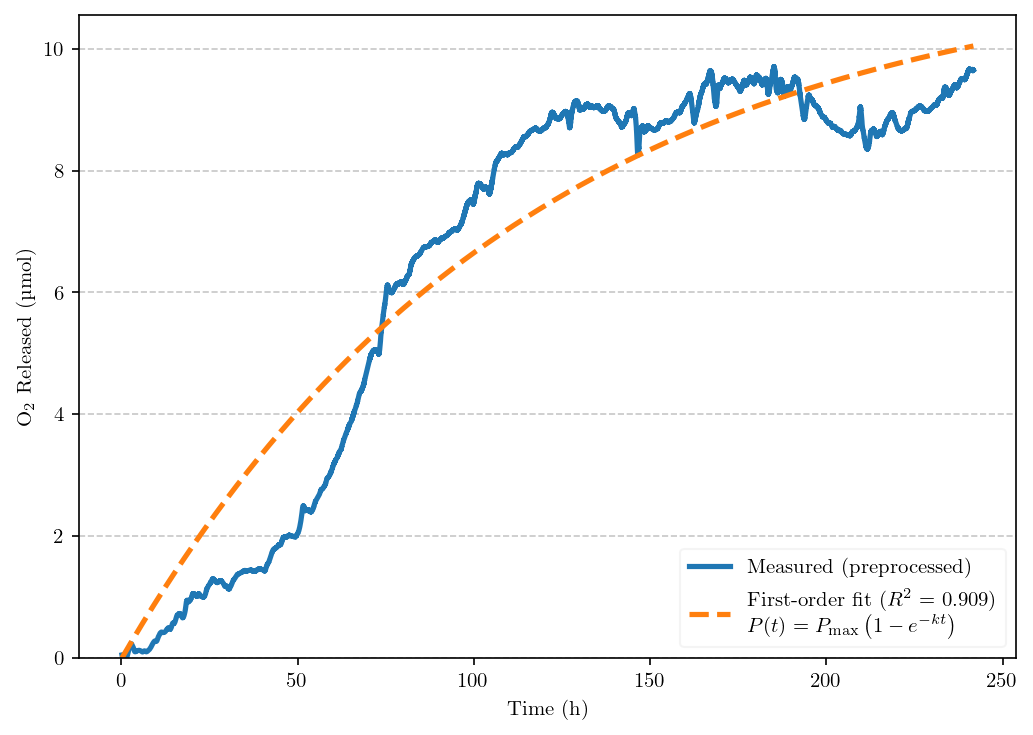

In [46]:
m2_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\RT\data files\O2_released_multi_volumes.csv"
df_m2 = pd.read_csv(m2_csv)
df_m2.columns = [c.strip() for c in df_m2.columns]

# Replace these with the series/column you want to fit
ngas_m2 = df_m2["O2 Released (µmol) - Vg=4.0mL"].values
time_m2 = df_m2["Time (s)"].values



# --- Clean: drop NaNs/Infs and ensure strictly increasing time (if needed) ---
mask = np.isfinite(time_m2) & np.isfinite(ngas_m2)
t = np.asarray(time_m2[mask], dtype=float)
y = np.asarray(ngas_m2[mask], dtype=float)

# If times are not strictly increasing, sort them (and y accordingly)
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y = t[order], y[order]

# Optionally, shift time to start at 0 for numerical stability (doesn't change k)
t0 = t.min()
t = t - t0

# --- First-order model ---
def first_order_model(t, P_max, k):
    # P(t) = P_max * (1 - exp(-k t))
    return P_max * (1.0 - np.exp(-k * t))

# --- Fit: robust initial guesses + nonnegative bounds ---
Pmax0 = float(np.nanmax(y))
dt = max(t.max() - t.min(), 1.0)  # seconds span; guard against zero
# choose half-life ~ 30% of data span as a reasonable default
k0 = np.log(2.0) / (0.3 * dt)
k0 = max(k0, 1e-9)

popt, pcov = curve_fit(
    first_order_model, t, y,
    p0=[Pmax0 if np.isfinite(Pmax0) and Pmax0 > 0 else (y[-1] if len(y) else 1.0), k0],
    bounds=([0.0, 0.0], [np.inf, np.inf]),
    maxfev=20000
)
P_max_fit, k_fit = popt
y_fit = first_order_model(t, *popt)

# --- Metrics (first-order only) ---
def aic(n, rss, k_params):
    return n * np.log(rss / n) + 2 * k_params

def bic(n, rss, k_params):
    return n * np.log(rss / n) + k_params * np.log(n)

n = len(y)
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
aic_val = aic(n, rss, 2)  # params: P_max, k
bic_val = bic(n, rss, 2)
t_half_h = np.log(2.0) / k_fit
t_half_s = t_half_h * 3600.0

# --- Show metrics ---
metrics = pd.DataFrame({
    "Model": ["First-order"],
    "P_max (µmol)": [P_max_fit],
    "k (1/h)": [k_fit],
    "Half-Life (s)": [t_half_s],
    "Half-Life (h)": [t_half_h],
    "RMSE (µmol)": [rmse],
    "R²": [r2],
    "AIC": [aic_val],
    "BIC": [bic_val],
})
display(metrics.round(6))

# --- Plot (Plot #3 analog: data + first-order fit only) ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t + t0, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t + t0, y_fit, "--", lw=2.5,
         label=fr"First-order fit ($R^2$ = {r2:.3f})" + "\n" + r"$P(t)=P_{\max}\left(1-e^{-kt}\right)$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.xlim()
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Logistic

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC
0,Logistic (bounded),9.11616,0.05528,68.853303,0.278473,0.992834,-2.223063e+06,-2.223028e+06


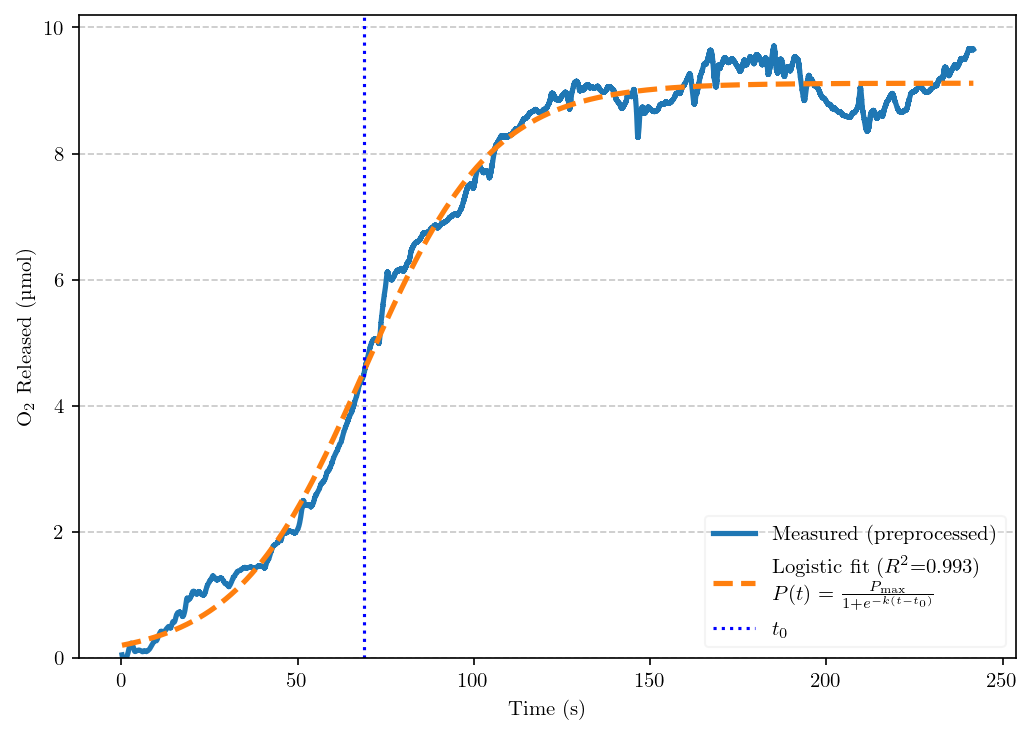

In [48]:

# ---- Load your preprocessed CSV ----
m2logi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\RT\data files\O2_released_multi_volumes.csv"
df_m2logi = pd.read_csv(m2logi_csv)
df_m2logi.columns = [c.strip() for c in df_m2logi.columns]

# Replace these with the series/column you want to fit
ngas_m2logi = df_m2logi["O2 Released (µmol) - Vg=4.0mL"].values
time_m2logi = df_m2logi["Time (s)"].values

# --- Clean NaNs/Infs ---
mask = np.isfinite(time_m2logi) & np.isfinite(ngas_m2logi)
t = np.asarray(time_m2logi[mask], dtype=float)
y = np.asarray(ngas_m2logi[mask], dtype=float)

# --- Logistic model ---
def logistic_model(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))

# --- Fit function with bounds from table ---
def fit_logistic_model(time, signal):
    P_max = np.max(signal)
    # initial guess for t0 = time at ~half max
    P0_init = time[np.argmin(np.abs(signal - P_max / 2.0))]
    k_init = 1.0 / (time[-1] - time[0] + 1e-9)  # avoid div/0
    
    # bounds according to table:
    # t0: [0.8 * P0_init, 1.2 * P0_init]
    # k: [0, 1]
    # P_max: [0.8 * P_max, 1.2 * P_max]
    bounds = [
        (0.8 * P0_init, 1.2 * P0_init),
        (0.0, 1.0),
        (0.8 * P_max, 1.2 * P_max)
    ]
    
    res = minimize(
        lambda p: mean_squared_error(signal, logistic_model(time, *p)),
        [P0_init, k_init, P_max],
        bounds=bounds
    )
    popt = res.x
    fit = logistic_model(time, *popt)
    return popt, fit

# --- Run fit ---
popt, y_fit = fit_logistic_model(t, y)
t0_fit, k_fit, Pmax_fit = popt

# --- Metrics ---
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 3
bic = n * np.log(rss / n) + 3 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Logistic (bounded)"],
    "P_max (µmol)": [Pmax_fit],
    "k (1/h)": [k_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic]
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic fit ($R^2$={r2:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit, linestyle=":", color="blue", label=r"$t_0$")
plt.xlabel("Time (s)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Gompertz -2.18 @RT

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC
0,"Gompertz (time-located, bounded)",9.24546,0.037268,57.390789,0.375553,0.986966,-1.702996e+06,-1.702961e+06


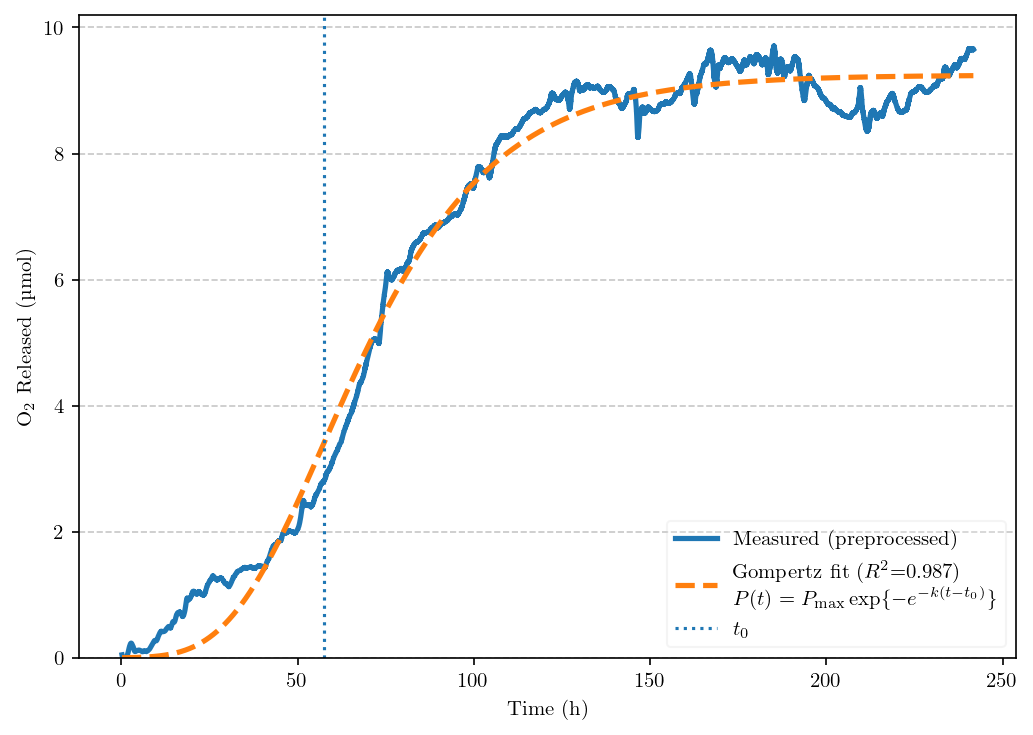

In [70]:


# ---- Load CSV ----
m2gom_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\RT\data files\O2_released_multi_volumes.csv"
df_m2gom = pd.read_csv(m2gom_csv)
df_m2gom.columns = [c.strip() for c in df_m2gom.columns]

ngas_m2gom = df_m2gom["O2 Released (µmol) - Vg=4.0mL"].values
time_m2gom = df_m2gom["Time (s)"].values  # actually hours in your dataset

# ---- Clean ----
mask = np.isfinite(time_m2gom) & np.isfinite(ngas_m2gom)
t_m2gom = np.asarray(time_m2gom[mask], dtype=float)
y_m2gom = np.asarray(ngas_m2gom[mask], dtype=float)

# Ensure increasing time
if np.any(np.diff(t_m2gom) <= 0):
    order = np.argsort(t_m2gom)
    t_m2gom = t_m2gom[order]
    y_m2gom = y_m2gom[order]

# ---- Gompertz (time-located form) ----
def gompertz_time_loc(t, t0, k, Pmax):
    return Pmax * np.exp(-np.exp(-k * (t - t0)))

# ---- Initial guesses ----
Pmax0 = float(np.max(y_m2gom))
t0_init = float(t_m2gom[np.argmin(np.abs(y_m2gom - 0.5 * Pmax0))])
dt = max(t_m2gom.max() - t_m2gom.min(), 1.0)  # hours
k_init = 1.0 / dt

# ---- Logistic-style bounds ----
lower_bounds = [0.8 * t0_init, 0.0, 0.8 * Pmax0]
upper_bounds = [1.2 * t0_init, 1.0, 1.2 * Pmax0]
p0 = [t0_init, k_init, Pmax0]

# ---- Fit ----
popt_m2gom, pcov_m2gom = curve_fit(
    gompertz_time_loc, t_m2gom, y_m2gom,
    p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=20000
)
t0_fit_m2gom, k_fit_m2gom, Pmax_fit_m2gom = popt_m2gom
y_fit_m2gom = gompertz_time_loc(t_m2gom, *popt_m2gom)

# ---- Metrics ----
rss_m2gom = np.sum((y_m2gom - y_fit_m2gom) ** 2)
rmse_m2gom = np.sqrt(mean_squared_error(y_m2gom, y_fit_m2gom))
r2_m2gom = r2_score(y_m2gom, y_fit_m2gom)
n_m2gom = len(y_m2gom)
aic_m2gom = n_m2gom * np.log(rss_m2gom / n_m2gom) + 2 * 3
bic_m2gom = n_m2gom * np.log(rss_m2gom / n_m2gom) + 3 * np.log(n_m2gom)

metrics_m2gom = pd.DataFrame({
    "Model": ["Gompertz (time-located, bounded)"],
    "P_max (µmol)": [Pmax_fit_m2gom],
    "k (1/h)": [k_fit_m2gom],    # hours
    "t0 (h)": [t0_fit_m2gom],
    "RMSE": [rmse_m2gom],
    "R²": [r2_m2gom],
    "AIC": [aic_m2gom],
    "BIC": [bic_m2gom]
})
display(metrics_m2gom.round(6))

# ---- Plot ----
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t_m2gom, y_m2gom, label="Measured (preprocessed)", lw=2.5)
plt.plot(t_m2gom, y_fit_m2gom, "--", lw=2.5,
         label=fr"Gompertz fit ($R^2$={r2_m2gom:.3f})" + "\n" + r"$P(t)=P_{\max}\exp\{-e^{-k(t-t_0)}\}$")
plt.axvline(t0_fit_m2gom, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()



# Gompertz with diff bounds

# M2 - 2.18mM @ 37 C

## First order

,Model,P_max (µmol),k (1/h),Half-Life (s),Half-Life (h),RMSE (µmol),R²,AIC,BIC
0,First-order,10.383359,0.052222,47782.987586,13.273052,0.206732,0.993661,-1.002539e+06,-1.002517e+06


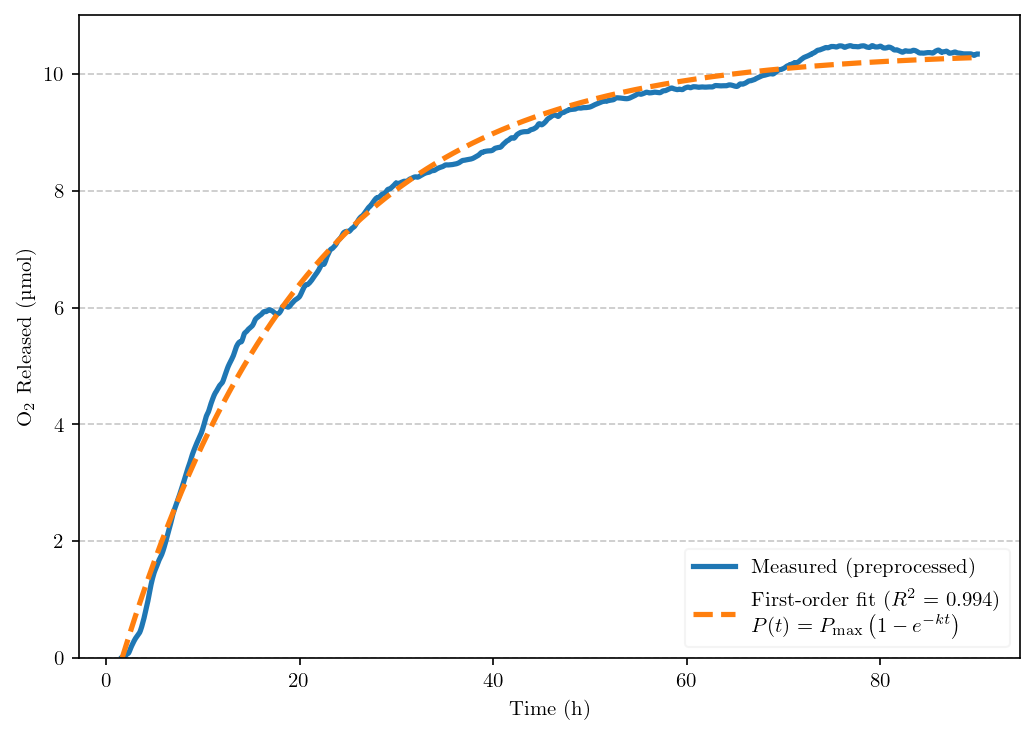

In [45]:
m22_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 2\2_O2_37DEG_released_multi_volumes.csv"
df_m22 = pd.read_csv(m22_csv)
df_m22.columns = [c.strip() for c in df_m22.columns]

# Replace these with the series/column you want to fit
ngas_m22 = df_m22["O2 Released (µmol) - Vg=4.0mL"].values
time_m22 = df_m22["Time (h)"].values


# --- Clean: drop NaNs/Infs and ensure strictly increasing time (if needed) ---
mask = np.isfinite(time_m22) & np.isfinite(ngas_m22)
t = np.asarray(time_m22[mask], dtype=float)
y = np.asarray(ngas_m22[mask], dtype=float)

# If times are not strictly increasing, sort them (and y accordingly)
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y = t[order], y[order]

# Optionally, shift time to start at 0 for numerical stability (doesn't change k)
t0 = t.min()
t = t - t0

# --- First-order model ---
def first_order_model(t, P_max, k):
    # P(t) = P_max * (1 - exp(-k t))
    return P_max * (1.0 - np.exp(-k * t))

# --- Fit: robust initial guesses + nonnegative bounds ---
Pmax0 = float(np.nanmax(y))
dt = max(t.max() - t.min(), 1.0)  # seconds span; guard against zero
# choose half-life ~ 30% of data span as a reasonable default
k0 = np.log(2.0) / (0.3 * dt)
k0 = max(k0, 1e-9)

popt, pcov = curve_fit(
    first_order_model, t, y,
    p0=[Pmax0 if np.isfinite(Pmax0) and Pmax0 > 0 else (y[-1] if len(y) else 1.0), k0],
    bounds=([0.0, 0.0], [np.inf, np.inf]),
    maxfev=20000
)
P_max_fit, k_fit = popt
y_fit = first_order_model(t, *popt)

# --- Metrics (first-order only) ---
def aic(n, rss, k_params):
    return n * np.log(rss / n) + 2 * k_params

def bic(n, rss, k_params):
    return n * np.log(rss / n) + k_params * np.log(n)

n = len(y)
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
aic_val = aic(n, rss, 2)  # params: P_max, k
bic_val = bic(n, rss, 2)
t_half_h = np.log(2.0) / k_fit
t_half_s = t_half_h * 3600.0

# --- Show metrics ---
metrics = pd.DataFrame({
    "Model": ["First-order"],
    "P_max (µmol)": [P_max_fit],
    "k (1/h)": [k_fit],
    "Half-Life (s)": [t_half_s],
    "Half-Life (h)": [t_half_h],
    "RMSE (µmol)": [rmse],
    "R²": [r2],
    "AIC": [aic_val],
    "BIC": [bic_val],
})
display(metrics.round(6))

# --- Plot (Plot #3 analog: data + first-order fit only) ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t + t0, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t + t0, y_fit, "--", lw=2.5,
         label=fr"First-order fit ($R^2$ = {r2:.3f})" + "\n" + r"$P(t)=P_{\max}\left(1-e^{-kt}\right)$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.xlim()
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Logistic

,Model,P_max (µmol),k (1/s),t0 (s),RMSE,R²,AIC,BIC
0,Logistic (bounded),10.011575,0.10356,15.813028,0.499658,0.962972,-441269.280885,-441237.271474


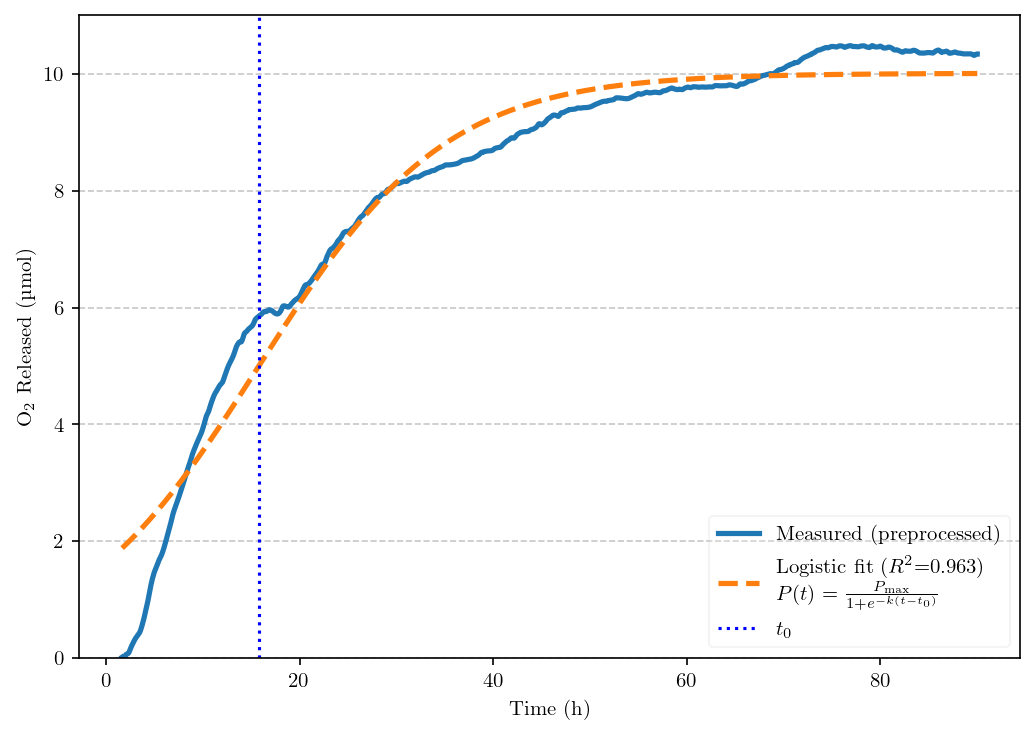

In [20]:
#logistic

m22logi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 2\2_O2_37DEG_released_multi_volumes.csv"
df_m22logi = pd.read_csv(m22logi_csv)
df_m22logi.columns = [c.strip() for c in df_m22logi.columns]

# Replace these with the series/column you want to fit
ngas_m22logi = df_m22logi["O2 Released (µmol) - Vg=4.0mL"].values
time_m22logi = df_m22logi["Time (h)"].values

# --- Clean NaNs/Infs ---
mask = np.isfinite(time_m22logi) & np.isfinite(ngas_m22logi)
t = np.asarray(time_m22logi[mask], dtype=float)
y = np.asarray(ngas_m22logi[mask], dtype=float)

# --- Logistic model ---
def logistic_model(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))

# --- Fit function with bounds from table ---
def fit_logistic_model(time, signal):
    P_max = np.max(signal)
    # initial guess for t0 = time at ~half max
    P0_init = time[np.argmin(np.abs(signal - P_max / 2.0))]
    k_init = 1.0 / (time[-1] - time[0] + 1e-9)  # avoid div/0
    
    # bounds according to table:
    # t0: [0.8 * P0_init, 1.2 * P0_init]
    # k: [0, 1]
    # P_max: [0.8 * P_max, 1.2 * P_max]
    bounds = [
        (0.8 * P0_init, 1.2 * P0_init),
        (0.0, 1.0),
        (0.8 * P_max, 1.2 * P_max)
    ]
    
    res = minimize(
        lambda p: mean_squared_error(signal, logistic_model(time, *p)),
        [P0_init, k_init, P_max],
        bounds=bounds
    )
    popt = res.x
    fit = logistic_model(time, *popt)
    return popt, fit

# --- Run fit ---
popt, y_fit = fit_logistic_model(t, y)
t0_fit, k_fit, Pmax_fit = popt

# --- Metrics ---
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 3
bic = n * np.log(rss / n) + 3 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Logistic (bounded)"],
    "P_max (µmol)": [Pmax_fit],
    "k (1/s)": [k_fit],
    "t0 (s)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic]
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic fit ($R^2$={r2:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit, linestyle=":", color="blue", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Modified logistic

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC,Converged
0,Logistic (robust),9.836935,0.109967,15.313789,0.497901,0.963455,-388357.307926,-388325.696891,True


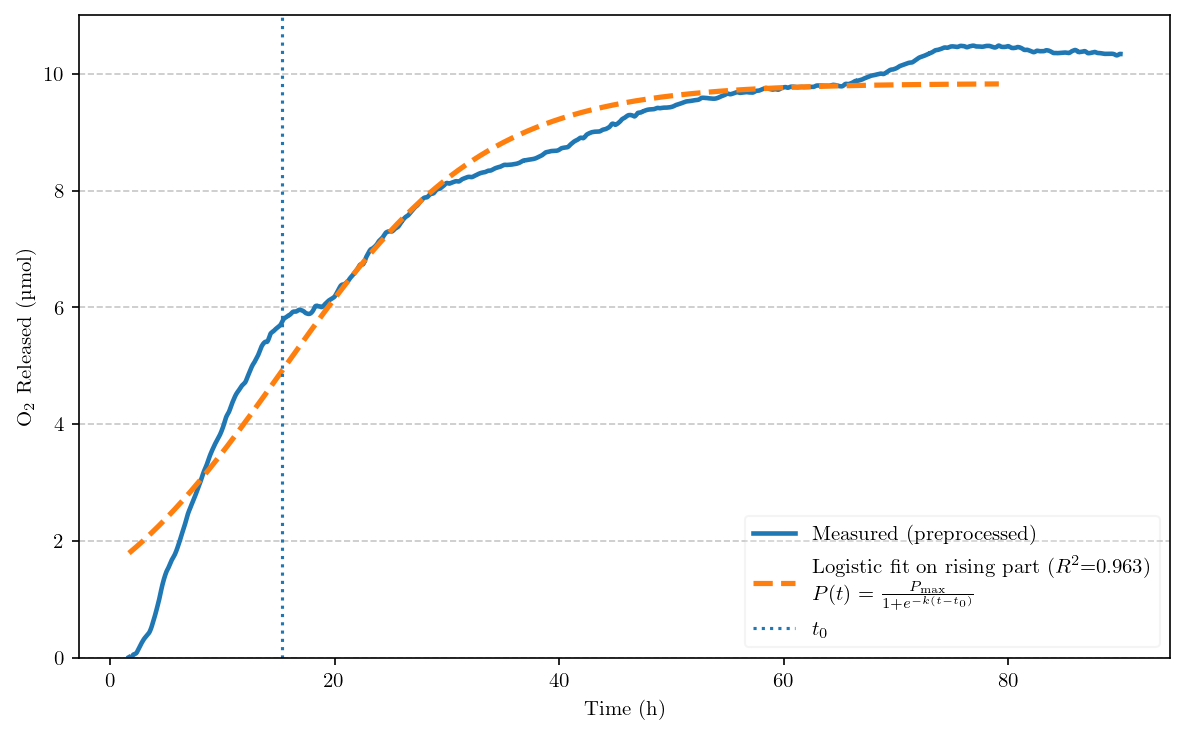

In [74]:
modified_logi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 2\2_O2_37DEG_released_multi_volumes.csv"
df_modified_logi = pd.read_csv(modified_logi_csv)
df_modified_logi.columns = [c.strip() for c in df_modified_logi.columns]

# Keep only positive O2 rows so time & signal stay aligned
df_modified_logi_pos = df_modified_logi[df_modified_logi["O2 Released (µmol) - Vg=4.0mL"] > 0].reset_index(drop=True)
t_full = df_modified_logi_pos["Time (h)"].to_numpy(dtype=float)
y_full = df_modified_logi_pos["O2 Released (µmol) - Vg=4.0mL"].to_numpy(dtype=float)


mask = np.isfinite(t_full) & np.isfinite(y_full)
t_full = t_full[mask]
y_full = y_full[mask]

idx_peak = np.argmax(y_full)
t = t_full[: idx_peak + 1]
y = y_full[: idx_peak + 1]


def logistic_model(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))


span = max(t.max() - t.min(), 1e-6)
Pmax0 = np.quantile(y, 0.98)  

# smooth just for slope estimation (doesn't affect fit)
win = max(5, int(0.03 * len(y)))  # ~3% of points
if win % 2 == 0:
    win += 1
y_smooth = pd.Series(y).rolling(window=win, center=True, min_periods=1).mean().to_numpy()
dy_dt = np.gradient(y_smooth, t)
i_inflect = int(np.argmax(dy_dt))
t0_init = float(t[i_inflect])
slope_max = float(max(dy_dt[i_inflect], 1e-12))  # avoid 0


# For logistic, slope at inflection ≈ k * Pmax / 4 -> k ≈ 4*slope/Pmax
k_init = float(4.0 * slope_max / max(Pmax0, 1e-9))
# keep k_init within a sane range w.r.t span
k_init = np.clip(k_init, 1e-6, 10.0 / span)


bounds = [
    (t.min(), t.max()),                 
    (1e-6, 10.0 / span),                
    (0.5 * Pmax0, 2.0 * max(y))         
]


def fit_logistic_model(time, signal):
    def obj(p):
        return mean_squared_error(signal, logistic_model(time, *p))
    x0 = np.array([t0_init, k_init, Pmax0], dtype=float)
    res = minimize(obj, x0, bounds=bounds, method="L-BFGS-B")
    # If optimizer struggles, fall back to a gentler start
    if not res.success:
        alt_x0 = np.array([np.median(time), 1.0 / span, np.max(signal)], dtype=float)
        res = minimize(obj, alt_x0, bounds=bounds, method="L-BFGS-B")
    popt = res.x
    fit = logistic_model(time, *popt)
    return popt, fit, res

popt, y_fit, res = fit_logistic_model(t, y)
t0_fit, k_fit, Pmax_fit = popt

# ---- Metrics ----
rss = np.sum((y - y_fit) ** 2)
rmse = float(np.sqrt(mean_squared_error(y, y_fit)))
r2 = float(r2_score(y, y_fit))
n = len(y)
aic = float(n * np.log(rss / n + 1e-12) + 2 * 3)
bic = float(n * np.log(rss / n + 1e-12) + 3 * np.log(max(n, 2)))

metrics = pd.DataFrame({
    "Model": ["Logistic (robust)"],
    "P_max (µmol)": [Pmax_fit],
    "k (1/h)": [k_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic],
    "Converged": [bool(res.success)]
})
display(metrics.round(6))


plt.figure(figsize=(8, 5), dpi=150)
plt.plot(t_full, y_full, label="Measured (preprocessed)", lw=2.2)  # show full series for context
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic fit on rising part ($R^2$={r2:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Gompertz

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC
0,"Gompertz (time-located, bounded)",10.126776,0.077961,10.737671,0.386793,0.977811,-604106.811759,-604074.802348


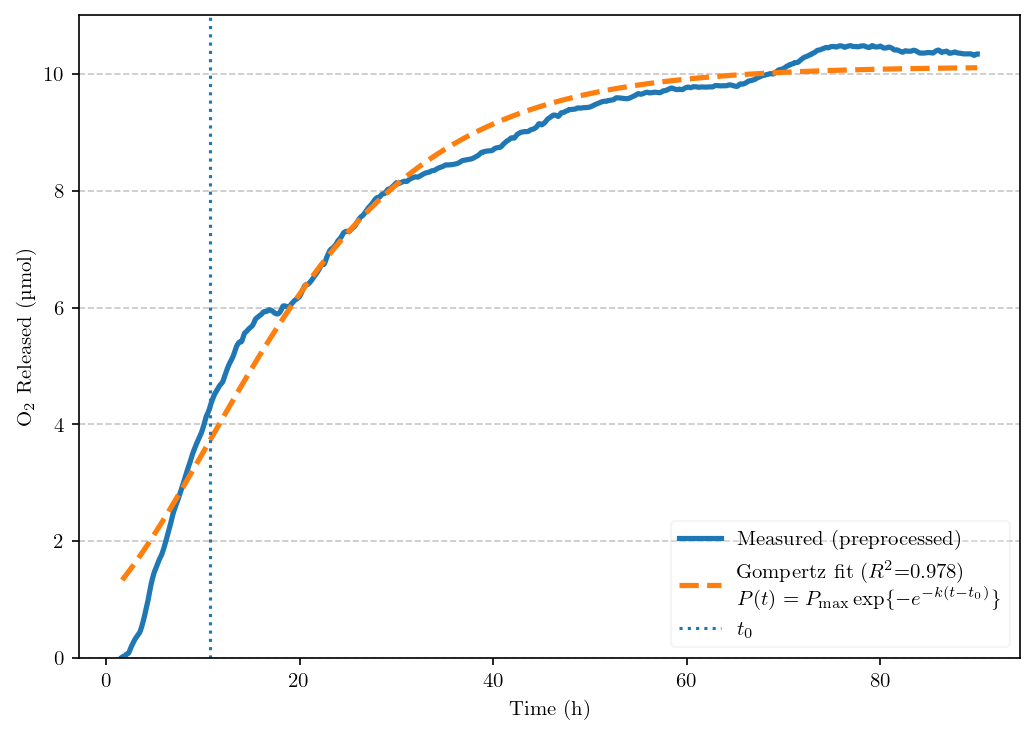

In [73]:

#gompertz
# ---- Load CSV ----
m3gom_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 2\2_O2_37DEG_released_multi_volumes.csv"
df_m3gom = pd.read_csv(m3gom_csv)
df_m3gom.columns = [c.strip() for c in df_m3gom.columns]

ngas_m3gom = df_m3gom["O2 Released (µmol) - Vg=4.0mL"].values
time_m3gom = df_m3gom["Time (h)"].values  # already in hours

# ---- Clean ----
mask = np.isfinite(time_m3gom) & np.isfinite(ngas_m3gom)
t_m3gom = np.asarray(time_m3gom[mask], dtype=float)
y_m3gom = np.asarray(ngas_m3gom[mask], dtype=float)

# Ensure increasing time
if np.any(np.diff(t_m3gom) <= 0):
    order = np.argsort(t_m3gom)
    t_m3gom = t_m3gom[order]
    y_m3gom = y_m3gom[order]

# ---- Gompertz (time-located form) ----
def gompertz_time_loc(t, t0, k, Pmax):
    return Pmax * np.exp(-np.exp(-k * (t - t0)))

# ---- Initial guesses ----
Pmax0 = float(np.max(y_m3gom))
t0_init = float(t_m3gom[np.argmin(np.abs(y_m3gom - 0.5 * Pmax0))])
dt = max(t_m3gom.max() - t_m3gom.min(), 1.0)  # hours
k_init = 1.0 / dt

# ---- Logistic-style bounds ----
lower_bounds = [0.8 * t0_init, 0.0, 0.8 * Pmax0]
upper_bounds = [1.2 * t0_init, 1.0, 1.2 * Pmax0]
p0 = [t0_init, k_init, Pmax0]

# ---- Fit ----
popt_m3gom, pcov_m3gom = curve_fit(
    gompertz_time_loc, t_m3gom, y_m3gom,
    p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=20000
)
t0_fit_m3gom, k_fit_m3gom, Pmax_fit_m3gom = popt_m3gom
y_fit_m3gom = gompertz_time_loc(t_m3gom, *popt_m3gom)

# ---- Metrics ----
rss_m3gom = np.sum((y_m3gom - y_fit_m3gom) ** 2)
rmse_m3gom = np.sqrt(mean_squared_error(y_m3gom, y_fit_m3gom))
r2_m3gom = r2_score(y_m3gom, y_fit_m3gom)
n_m3gom = len(y_m3gom)
aic_m3gom = n_m3gom * np.log(rss_m3gom / n_m3gom) + 2 * 3
bic_m3gom = n_m3gom * np.log(rss_m3gom / n_m3gom) + 3 * np.log(n_m3gom)

metrics_m3gom = pd.DataFrame({
    "Model": ["Gompertz (time-located, bounded)"],
    "P_max (µmol)": [Pmax_fit_m3gom],
    "k (1/h)": [k_fit_m3gom],    # hours
    "t0 (h)": [t0_fit_m3gom],
    "RMSE": [rmse_m3gom],
    "R²": [r2_m3gom],
    "AIC": [aic_m3gom],
    "BIC": [bic_m3gom]
})
display(metrics_m3gom.round(6))

# ---- Plot ----
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t_m3gom, y_m3gom, label="Measured (preprocessed)", lw=2.5)
plt.plot(t_m3gom, y_fit_m3gom, "--", lw=2.5,
         label=fr"Gompertz fit ($R^2$={r2_m3gom:.3f})" + "\n" + r"$P(t)=P_{\max}\exp\{-e^{-k(t-t_0)}\}$")
plt.axvline(t0_fit_m3gom, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# Gompertz with different bounds

# M3 - 1.2mM @ RT

## First order

,Model,P_max (µmol),k (1/h),Half-Life (s),Half-Life (h),RMSE (µmol),R²,AIC,BIC
0,First-order,3.958929,0.050603,49311.499776,13.697639,0.700288,0.587449,-602437.601363,-602414.305994


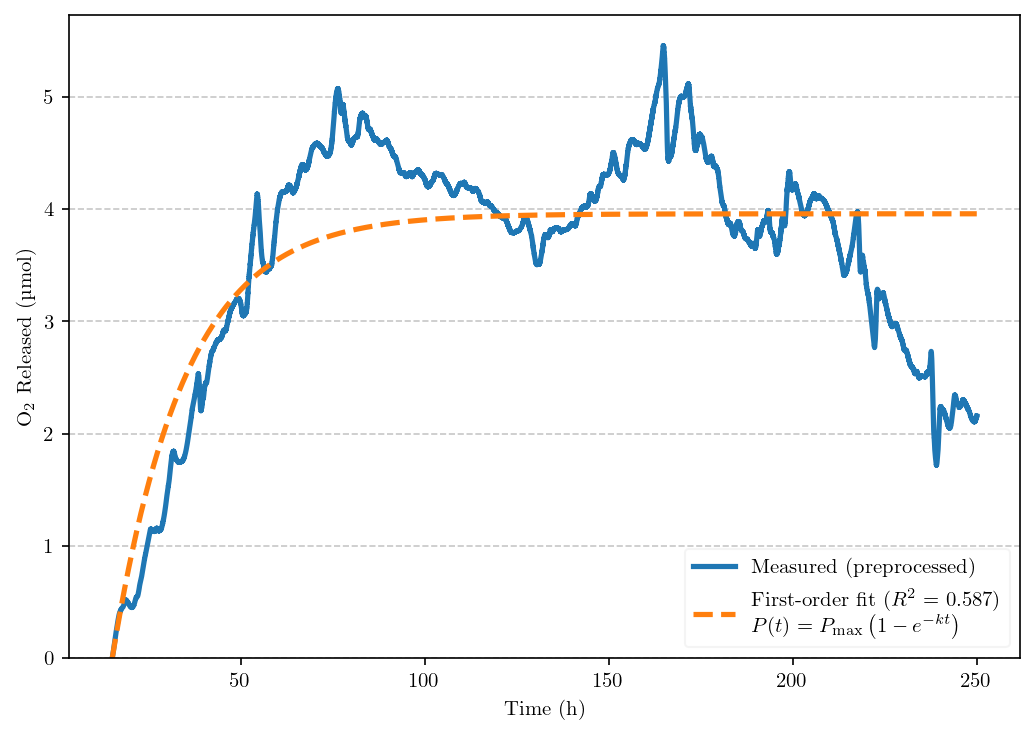

In [42]:
m3_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\RT\Data files\M3_1.2mM_RT_pressure_o2_release.csv"
df_m3 = pd.read_csv(m3_csv)
df_m3.columns = [c.strip() for c in df_m3.columns]

# Replace these with the series/column you want to fit

df_m3_pos = df_m3[df_m3["O2 Released (µmol)"] > 0].reset_index(drop=True)

ngas_m3 = df_m3_pos["O2 Released (µmol)"].values
time_m3 = df_m3_pos["Time (h)"].values


# --- Clean: drop NaNs/Infs and ensure strictly increasing time (if needed) ---
mask = np.isfinite(time_m3) & np.isfinite(ngas_m3)
t = np.asarray(time_m3[mask], dtype=float)
y = np.asarray(ngas_m3[mask], dtype=float)

# If times are not strictly increasing, sort them (and y accordingly)
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y = t[order], y[order]

# Optionally, shift time to start at 0 for numerical stability (doesn't change k)
t0 = t.min()
t = t - t0

# --- First-order model ---
def first_order_model(t, P_max, k):
    # P(t) = P_max * (1 - exp(-k t))
    return P_max * (1.0 - np.exp(-k * t))

# --- Fit: robust initial guesses + nonnegative bounds ---
Pmax0 = float(np.nanmax(y))
dt = max(t.max() - t.min(), 1.0)  # seconds span; guard against zero
# choose half-life ~ 30% of data span as a reasonable default
k0 = np.log(2.0) / (0.3 * dt)
k0 = max(k0, 1e-9)

popt, pcov = curve_fit(
    first_order_model, t, y,
    p0=[Pmax0 if np.isfinite(Pmax0) and Pmax0 > 0 else (y[-1] if len(y) else 1.0), k0],
    bounds=([0.0, 0.0], [np.inf, np.inf]),
    maxfev=20000
)
P_max_fit, k_fit = popt
y_fit = first_order_model(t, *popt)

# --- Metrics (first-order only) ---
def aic(n, rss, k_params):
    return n * np.log(rss / n) + 2 * k_params

def bic(n, rss, k_params):
    return n * np.log(rss / n) + k_params * np.log(n)

n = len(y)
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
aic_val = aic(n, rss, 2)  # params: P_max, k
bic_val = bic(n, rss, 2)
t_half_h = np.log(2.0) / k_fit
t_half_s = t_half_h * 3600.0

# --- Show metrics ---
metrics = pd.DataFrame({
    "Model": ["First-order"],
    "P_max (µmol)": [P_max_fit],
    "k (1/h)": [k_fit],
    "Half-Life (s)": [t_half_s],
    "Half-Life (h)": [t_half_h],
    "RMSE (µmol)": [rmse],
    "R²": [r2],
    "AIC": [aic_val],
    "BIC": [bic_val],
})
display(metrics.round(6))

# --- Plot (Plot #3 analog: data + first-order fit only) ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t + t0, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t + t0, y_fit, "--", lw=2.5,
         label=fr"First-order fit ($R^2$ = {r2:.3f})" + "\n" + r"$P(t)=P_{\max}\left(1-e^{-kt}\right)$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.xlim()
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Logistic

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC
0,Logistic (bounded),6.535223,0.002207,42.187864,1.069298,0.038119,113307.267013,113342.210067


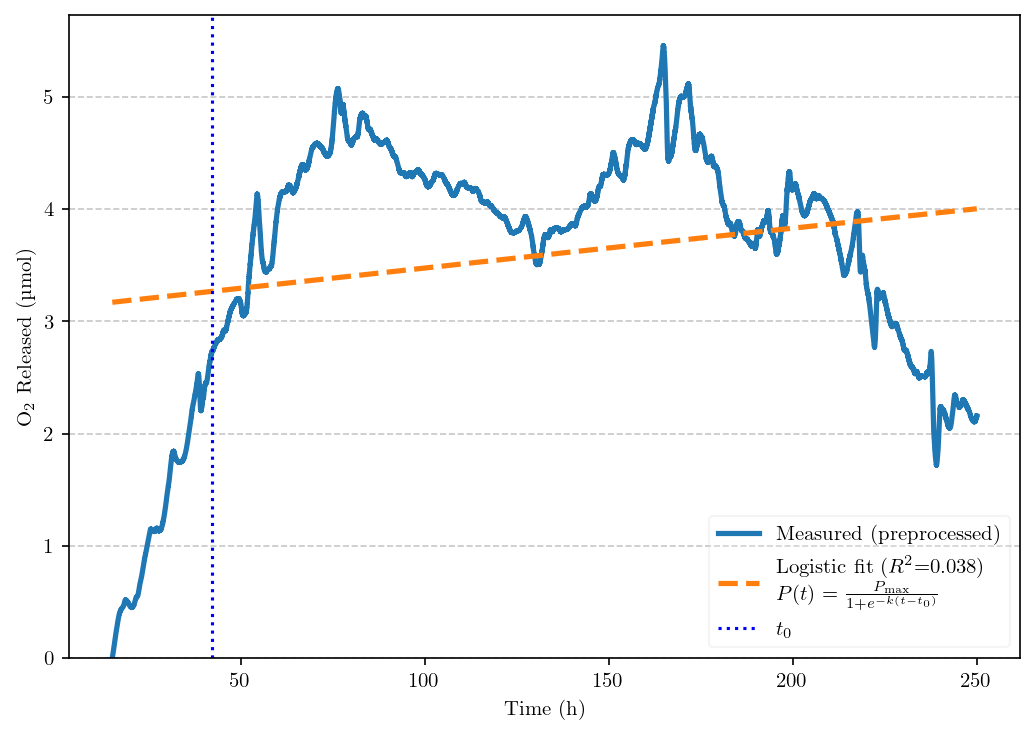

In [50]:

m3logi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\RT\Data files\M3_1.2mM_RT_pressure_o2_release.csv"
df_m3logi = pd.read_csv(m3logi_csv)
df_m3logi.columns = [c.strip() for c in df_m3logi.columns]

# # Replace these with the series/column you want to fit
# ngas_m3logi = df_m3logi["O2 Released (µmol)"].values
# time_m3logi = df_m3logi["Time (h)"].values



df_m3logi_pos = df_m3logi[df_m3logi["O2 Released (µmol)"] > 0].reset_index(drop=True)

ngas_m3logi = df_m3logi_pos["O2 Released (µmol)"].values
time_m3logi = df_m3logi_pos["Time (h)"].values


# --- Clean NaNs/Infs ---
mask = np.isfinite(time_m3logi) & np.isfinite(ngas_m3logi)
t = np.asarray(time_m3logi[mask], dtype=float)
y = np.asarray(ngas_m3logi[mask], dtype=float)

# --- Logistic model ---
def logistic_model(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))

# --- Fit function with bounds from table ---
def fit_logistic_model(time, signal):
    P_max = np.max(signal)
    # initial guess for t0 = time at ~half max
    P0_init = time[np.argmin(np.abs(signal - P_max / 2.0))]
    k_init = 1.0 / (time[-1] - time[0] + 1e-9)  # avoid div/0
    
    # bounds according to table:
    # t0: [0.8 * P0_init, 1.2 * P0_init]
    # k: [0, 1]
    # P_max: [0.8 * P_max, 1.2 * P_max]
    bounds = [
        (0.8 * P0_init, 1.2 * P0_init),
        (0.0, 1.0),
        (0.8 * P_max, 1.2 * P_max)
    ]
    
    res = minimize(
        lambda p: mean_squared_error(signal, logistic_model(time, *p)),
        [P0_init, k_init, P_max],
        bounds=bounds
    )
    popt = res.x
    fit = logistic_model(time, *popt)
    return popt, fit

# --- Run fit ---
popt, y_fit = fit_logistic_model(t, y)
t0_fit, k_fit, Pmax_fit = popt

# --- Metrics ---
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 3
bic = n * np.log(rss / n) + 3 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Logistic (bounded)"],
    "P_max (µmol)": [Pmax_fit],
    "k (1/h)": [k_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic]
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic fit ($R^2$={r2:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit, linestyle=":", color="blue", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

Bounds too restrcitive

Changed guesses and bounds:

1. Instead of t0 = Pmax/2, it is set to point of maximum slope.
2. Initial guess for K was K = 1/time span
instead the regular logistic property for slope at inflection point is k.pmax/4. so k = 4.slopemax / pmax.

3. instead of to being, it is between tmin and tmax

# Modified logistic

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC,Converged
0,Logistic (robust),4.386141,0.066795,36.765951,0.40878,0.885367,-964281.617595,-964248.025394,True


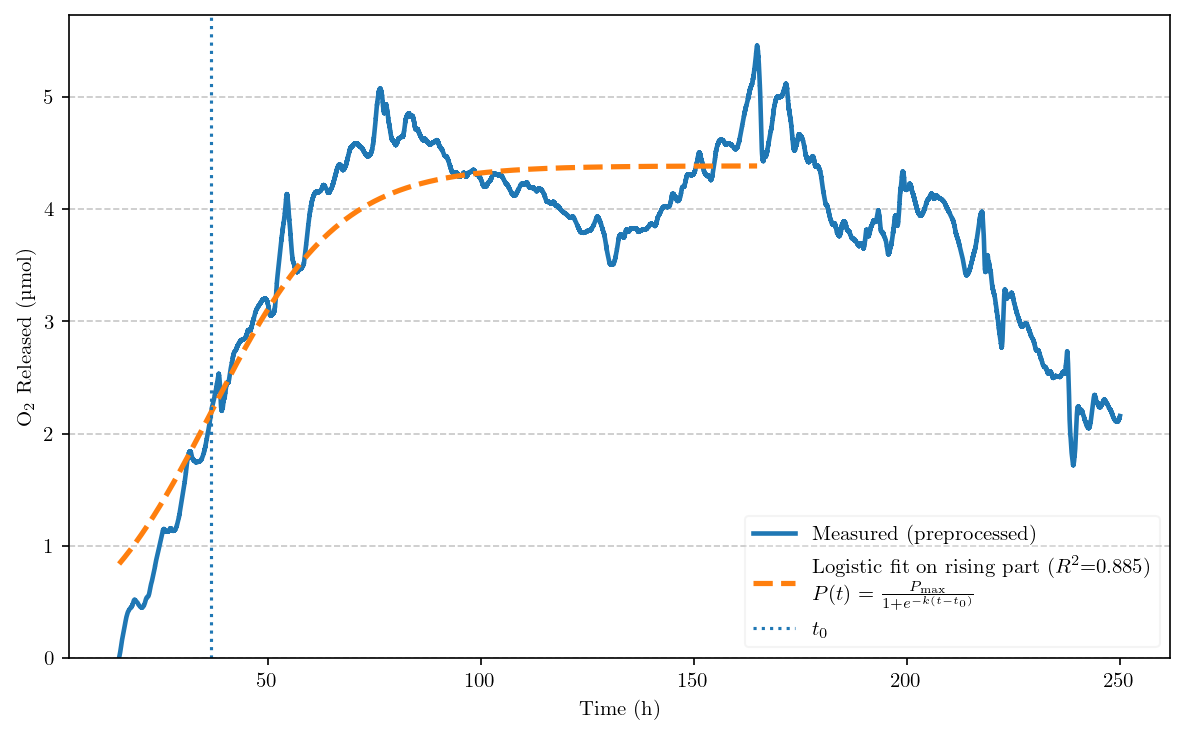

In [31]:


m3logi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\RT\Data files\M3_1.2mM_RT_pressure_o2_release.csv"
df_m3logi = pd.read_csv(m3logi_csv)
df_m3logi.columns = [c.strip() for c in df_m3logi.columns]

# Keep only positive O2 rows so time & signal stay aligned
df_m3logi_pos = df_m3logi[df_m3logi["O2 Released (µmol)"] > 0].reset_index(drop=True)
t_full = df_m3logi_pos["Time (h)"].to_numpy(dtype=float)
y_full = df_m3logi_pos["O2 Released (µmol)"].to_numpy(dtype=float)


mask = np.isfinite(t_full) & np.isfinite(y_full)
t_full = t_full[mask]
y_full = y_full[mask]

.
idx_peak = np.argmax(y_full)
t = t_full[: idx_peak + 1]
y = y_full[: idx_peak + 1]


def logistic_model(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))


span = max(t.max() - t.min(), 1e-6)
Pmax0 = np.quantile(y, 0.98)  

# smooth just for slope estimation (doesn't affect fit)
win = max(5, int(0.03 * len(y)))  # ~3% of points
if win % 2 == 0:
    win += 1
y_smooth = pd.Series(y).rolling(window=win, center=True, min_periods=1).mean().to_numpy()
dy_dt = np.gradient(y_smooth, t)
i_inflect = int(np.argmax(dy_dt))
t0_init = float(t[i_inflect])
slope_max = float(max(dy_dt[i_inflect], 1e-12))  # avoid 0


# For logistic, slope at inflection ≈ k * Pmax / 4 -> k ≈ 4*slope/Pmax
k_init = float(4.0 * slope_max / max(Pmax0, 1e-9))
# keep k_init within a sane range w.r.t span
k_init = np.clip(k_init, 1e-6, 10.0 / span)


bounds = [
    (t.min(), t.max()),                 
    (1e-6, 10.0 / span),                
    (0.5 * Pmax0, 2.0 * max(y))         
]


def fit_logistic_model(time, signal):
    def obj(p):
        return mean_squared_error(signal, logistic_model(time, *p))
    x0 = np.array([t0_init, k_init, Pmax0], dtype=float)
    res = minimize(obj, x0, bounds=bounds, method="L-BFGS-B")
    # If optimizer struggles, fall back to a gentler start
    if not res.success:
        alt_x0 = np.array([np.median(time), 1.0 / span, np.max(signal)], dtype=float)
        res = minimize(obj, alt_x0, bounds=bounds, method="L-BFGS-B")
    popt = res.x
    fit = logistic_model(time, *popt)
    return popt, fit, res

popt, y_fit, res = fit_logistic_model(t, y)
t0_fit, k_fit, Pmax_fit = popt

# ---- Metrics ----
rss = np.sum((y - y_fit) ** 2)
rmse = float(np.sqrt(mean_squared_error(y, y_fit)))
r2 = float(r2_score(y, y_fit))
n = len(y)
aic = float(n * np.log(rss / n + 1e-12) + 2 * 3)
bic = float(n * np.log(rss / n + 1e-12) + 3 * np.log(max(n, 2)))

metrics = pd.DataFrame({
    "Model": ["Logistic (robust)"],
    "P_max (µmol)": [Pmax_fit],
    "k (1/h)": [k_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic],
    "Converged": [bool(res.success)]
})
display(metrics.round(6))


plt.figure(figsize=(8, 5), dpi=150)
plt.plot(t_full, y_full, label="Measured (preprocessed)", lw=2.2)  # show full series for context
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic fit on rising part ($R^2$={r2:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# Gompertz

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC
0,"Gompertz (time-located, bounded)",6.549794,0.004442,33.775593,1.155461,-0.123142,244355.205801,244390.148855


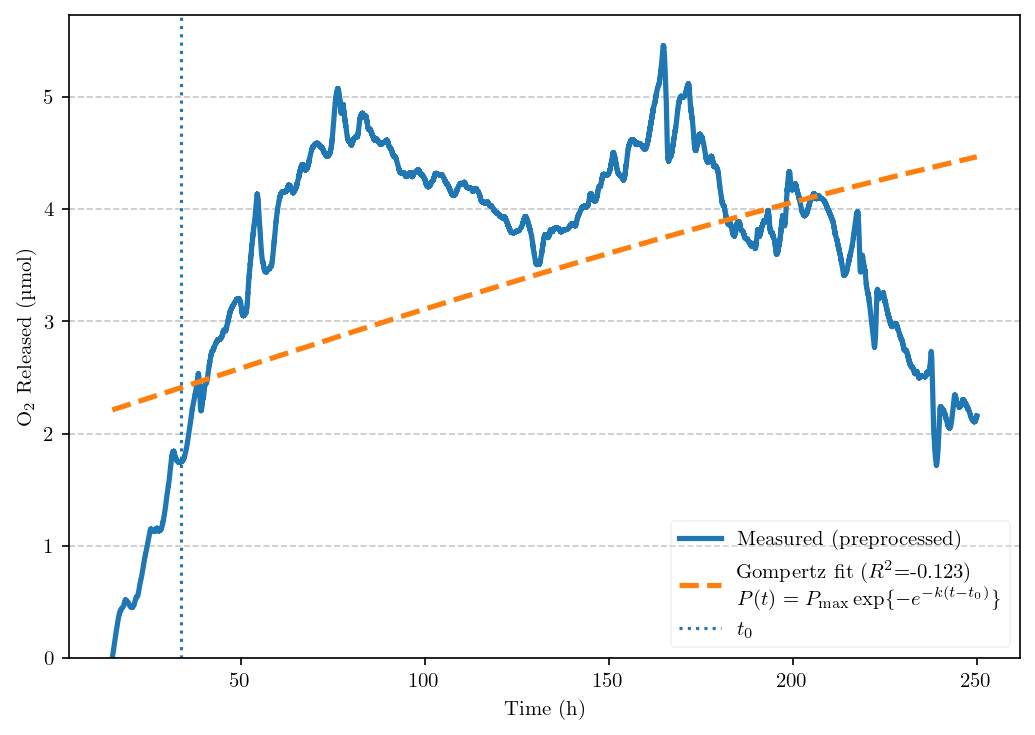

In [75]:
# ---- Load CSV ----
m4gom_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\RT\Data files\M3_1.2mM_RT_pressure_o2_release.csv"
df_m4gom = pd.read_csv(m4gom_csv)
df_m4gom.columns = [c.strip() for c in df_m4gom.columns]

df_m4gom_pos = df_m4gom[df_m4gom["O2 Released (µmol)"] > 0].reset_index(drop=True)
ngas_m4gom = df_m4gom_pos["O2 Released (µmol)"].to_numpy(dtype=float)
time_m4gom = df_m4gom_pos["Time (h)"].to_numpy(dtype=float)

# ---- Clean ----
mask = np.isfinite(time_m4gom) & np.isfinite(ngas_m4gom)
t_m4gom = np.asarray(time_m4gom[mask], dtype=float)
y_m4gom = np.asarray(ngas_m4gom[mask], dtype=float)

# Ensure increasing time
if np.any(np.diff(t_m4gom) <= 0):
    order = np.argsort(t_m4gom)
    t_m4gom = t_m4gom[order]
    y_m4gom = y_m4gom[order]

# ---- Gompertz (time-located form) ----
def gompertz_time_loc(t, t0, k, Pmax):
    return Pmax * np.exp(-np.exp(-k * (t - t0)))

# ---- Initial guesses ----
Pmax0 = float(np.max(y_m4gom))
t0_init = float(t_m4gom[np.argmin(np.abs(y_m4gom - 0.5 * Pmax0))])
dt = max(t_m4gom.max() - t_m4gom.min(), 1.0)  # hours
k_init = 1.0 / dt

# ---- Logistic-style bounds ----
lower_bounds = [0.8 * t0_init, 0.0, 0.8 * Pmax0]
upper_bounds = [1.2 * t0_init, 1.0, 1.2 * Pmax0]
p0 = [t0_init, k_init, Pmax0]

# ---- Fit ----
popt_m4gom, pcov_m4gom = curve_fit(
    gompertz_time_loc, t_m4gom, y_m4gom,
    p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=20000
)
t0_fit_m4gom, k_fit_m4gom, Pmax_fit_m4gom = popt_m4gom
y_fit_m4gom = gompertz_time_loc(t_m4gom, *popt_m4gom)

# ---- Metrics ----
rss_m4gom = np.sum((y_m4gom - y_fit_m4gom) ** 2)
rmse_m4gom = np.sqrt(mean_squared_error(y_m4gom, y_fit_m4gom))
r2_m4gom = r2_score(y_m4gom, y_fit_m4gom)
n_m4gom = len(y_m4gom)
aic_m4gom = n_m4gom * np.log(rss_m4gom / n_m4gom) + 2 * 3
bic_m4gom = n_m4gom * np.log(rss_m4gom / n_m4gom) + 3 * np.log(n_m4gom)

metrics_m4gom = pd.DataFrame({
    "Model": ["Gompertz (time-located, bounded)"],
    "P_max (µmol)": [Pmax_fit_m4gom],
    "k (1/h)": [k_fit_m4gom],    # hours
    "t0 (h)": [t0_fit_m4gom],
    "RMSE": [rmse_m4gom],
    "R²": [r2_m4gom],
    "AIC": [aic_m4gom],
    "BIC": [bic_m4gom]
})
display(metrics_m4gom.round(6))

# ---- Plot ----
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t_m4gom, y_m4gom, label="Measured (preprocessed)", lw=2.5)
plt.plot(t_m4gom, y_fit_m4gom, "--", lw=2.5,
         label=fr"Gompertz fit ($R^2$={r2_m4gom:.3f})" + "\n" + r"$P(t)=P_{\max}\exp\{-e^{-k(t-t_0)}\}$")
plt.axvline(t0_fit_m4gom, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# Gompertz with different bounds

# a bit relaxed bounds

Fitting only on the growth phase

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC
0,"Gompertz (time-located, bounded)",4.75843,0.063259,33.136167,0.203831,0.98048,-971769.320188,-971737.431063


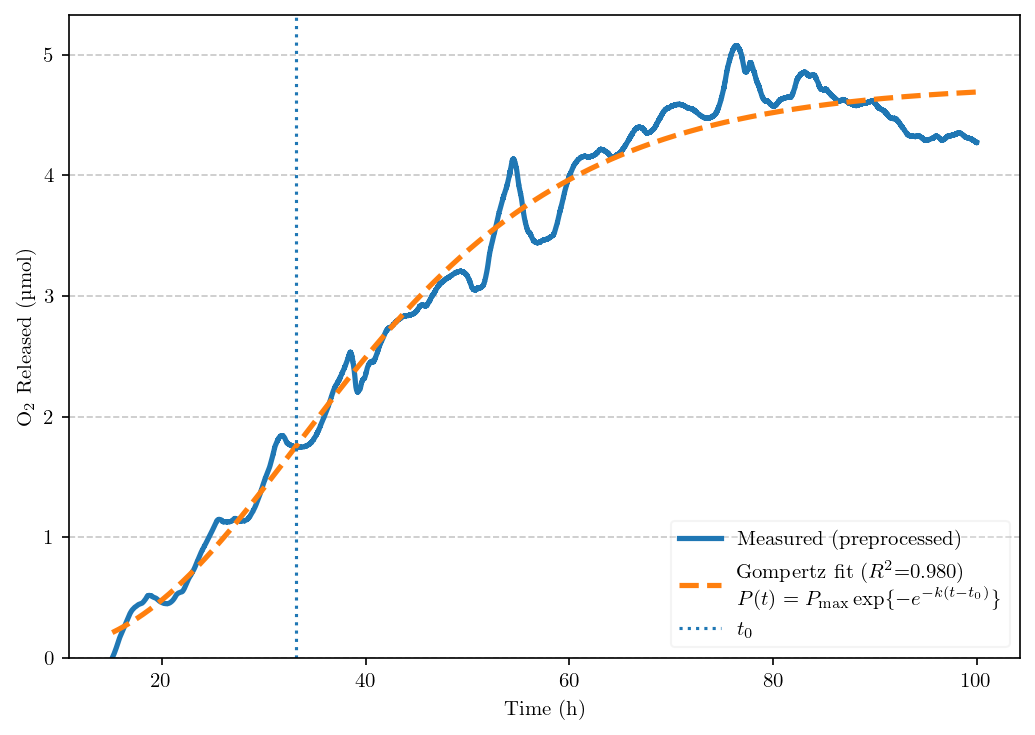

In [78]:

m4gom_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\RT\Data files\M3_1.2mM_RT_pressure_o2_release.csv"
df_m4gom = pd.read_csv(m4gom_csv)
df_m4gom.columns = [c.strip() for c in df_m4gom.columns]

df_m4gom_pos = df_m4gom[df_m4gom["O2 Released (µmol)"] > 0].reset_index(drop=True)
ngas_m4gom = df_m4gom_pos["O2 Released (µmol)"].to_numpy(dtype=float)
time_m4gom = df_m4gom_pos["Time (h)"].to_numpy(dtype=float)


mask = np.isfinite(time_m4gom) & np.isfinite(ngas_m4gom)


t_m4gom = np.asarray(time_m4gom[mask], dtype=float)
y_m4gom = np.asarray(ngas_m4gom[mask], dtype=float)

mask2 = t_m4gom < 100
t_m4gom = t_m4gom[mask2]
y_m4gom = y_m4gom[mask2]



# Ensure increasing time
if np.any(np.diff(t_m4gom) <= 0):
    order = np.argsort(t_m4gom)
    t_m4gom = t_m4gom[order]
    y_m4gom = y_m4gom[order]


def gompertz_time_loc(t, t0, k, Pmax):
    return Pmax * np.exp(-np.exp(-k * (t - t0)))


Pmax0 = float(np.max(y_m4gom))
t0_init = float(t_m4gom[np.argmin(np.abs(y_m4gom - 0.5 * Pmax0))])
dt = max(t_m4gom.max() - t_m4gom.min(), 1.0)  # hours
k_init = 1.0 / dt


lower_bounds = [0, 0, 0]
upper_bounds = [np.inf, np.inf, np.inf]
p0 = [t0_init, k_init, Pmax0]


popt_m4gom, pcov_m4gom = curve_fit(
    gompertz_time_loc, t_m4gom, y_m4gom,
    p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=20000
)
t0_fit_m4gom, k_fit_m4gom, Pmax_fit_m4gom = popt_m4gom
y_fit_m4gom = gompertz_time_loc(t_m4gom, *popt_m4gom)

# ---- Metrics ----
rss_m4gom = np.sum((y_m4gom - y_fit_m4gom) ** 2)
rmse_m4gom = np.sqrt(mean_squared_error(y_m4gom, y_fit_m4gom))
r2_m4gom = r2_score(y_m4gom, y_fit_m4gom)
n_m4gom = len(y_m4gom)
aic_m4gom = n_m4gom * np.log(rss_m4gom / n_m4gom) + 2 * 3
bic_m4gom = n_m4gom * np.log(rss_m4gom / n_m4gom) + 3 * np.log(n_m4gom)

metrics_m4gom = pd.DataFrame({
    "Model": ["Gompertz (time-located, bounded)"],
    "P_max (µmol)": [Pmax_fit_m4gom],
    "k (1/h)": [k_fit_m4gom],    # hours
    "t0 (h)": [t0_fit_m4gom],
    "RMSE": [rmse_m4gom],
    "R²": [r2_m4gom],
    "AIC": [aic_m4gom],
    "BIC": [bic_m4gom]
})
display(metrics_m4gom.round(6))

# ---- Plot ----
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t_m4gom, y_m4gom, label="Measured (preprocessed)", lw=2.5)
plt.plot(t_m4gom, y_fit_m4gom, "--", lw=2.5,
         label=fr"Gompertz fit ($R^2$={r2_m4gom:.3f})" + "\n" + r"$P(t)=P_{\max}\exp\{-e^{-k(t-t_0)}\}$")
plt.axvline(t0_fit_m4gom, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

,Model,P_max (µmol),k (1/h),t0 (h),beta (µmol/h),t_d (h),RMSE,R²,AIC,BIC
0,Logistic - linear decline (bounded),4.366529,0.105935,37.747242,0.048226,198.387428,0.333674,0.906337,-1.856020e+06,-1.855962e+06


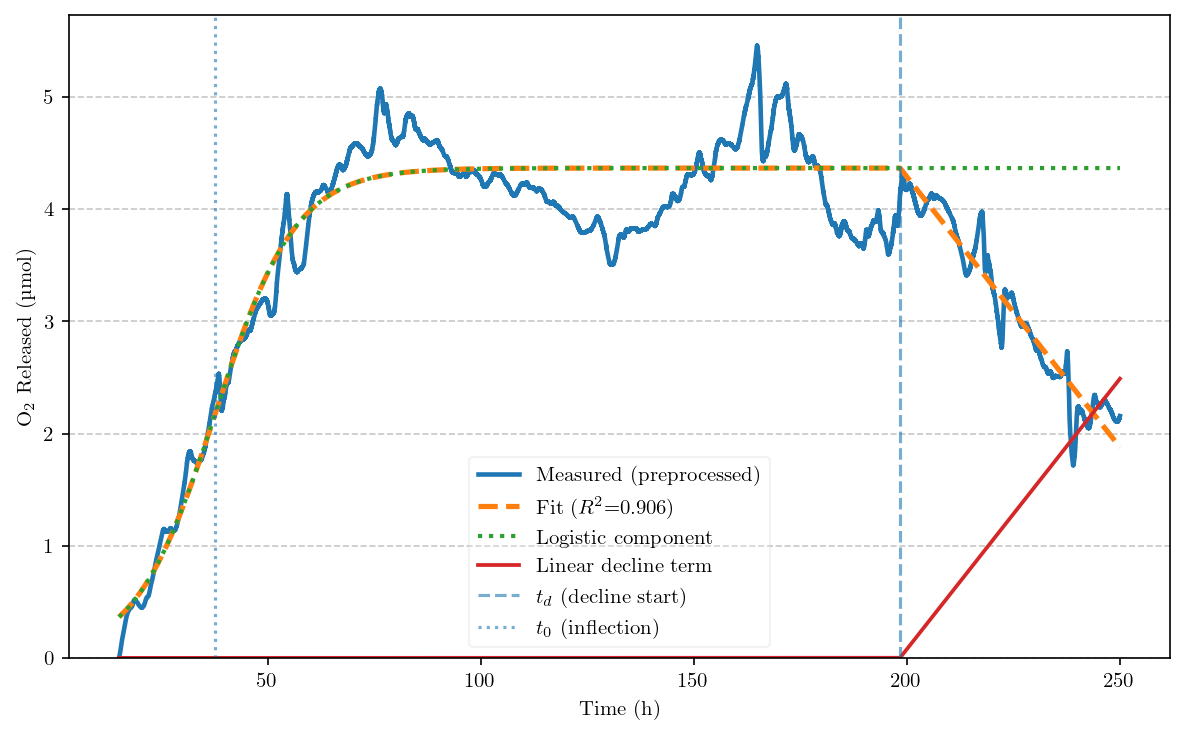

In [79]:

m4ld_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\RT\Data files\M3_1.2mM_RT_pressure_o2_release.csv"
df_m4ld = pd.read_csv(m4ld_csv)
df_m4ld.columns = [c.strip() for c in df_m4ld.columns]

# keep positive O2 only (optional; remove if you want all)
df_m4ld_pos = df_m4ld[df_m4ld["O2 Released (µmol)"] > 0].reset_index(drop=True)
y_m4ld = df_m4ld_pos["O2 Released (µmol)"].to_numpy(dtype=float)
t_m4ld = df_m4ld_pos["Time (h)"].to_numpy(dtype=float)

# clean NaNs/Infs
mask = np.isfinite(t_m4ld) & np.isfinite(y_m4ld)
t_m4ld = t_m4ld[mask]
y_m4ld = y_m4ld[mask]

# ensure increasing time
if np.any(np.diff(t_m4ld) <= 0):
    order = np.argsort(t_m4ld)
    t_m4ld = t_m4ld[order]
    y_m4ld = y_m4ld[order]

# =========================
# MODEL: Logistic × 1  -  Linear decline after t_d
# P(t) = Pmax/(1+exp(-k(t-t0)))  -  beta * max(0, t - t_d)
# =========================
def relu(x):
    return np.maximum(0.0, x)

def logistic(t, t0, k, Pmax):
    return Pmax / (1.0 + np.exp(-k * (t - t0)))

def growth_minus_linear_decay(t, t0, k, Pmax, beta, td):
    return logistic(t, t0, k, Pmax) - beta * relu(t - td)

# =========================
# INITIAL GUESSES
# =========================
span = max(t_m4ld.max() - t_m4ld.min(), 1e-6)
Pmax0_m4ld = float(np.max(y_m4ld))
# t0 near half-maximum
t0_init_m4ld = float(t_m4ld[np.argmin(np.abs(y_m4ld - 0.5 * Pmax0_m4ld))])
# k around 1/span
k_init_m4ld = max(1.0 / span, 1e-6)
# td at the observed peak time
idx_peak_m4ld = int(np.argmax(y_m4ld))
td_init_m4ld = float(t_m4ld[idx_peak_m4ld])

# Estimate tail slope (last ~20% points). If positive slope, set small beta.
tail_start = int(max(len(t_m4ld) * 0.8, idx_peak_m4ld))
if tail_start < len(t_m4ld) - 2:
    tt = t_m4ld[tail_start:]
    yy = y_m4ld[tail_start:]
    A = np.vstack([tt, np.ones_like(tt)]).T
    slope, intercept = np.linalg.lstsq(A, yy, rcond=None)[0]
    beta_init_m4ld = float(max(-slope, 0.0))  # decline rate must be >= 0
else:
    beta_init_m4ld = Pmax0_m4ld / span * 0.1  # gentle default

p0_m4ld = [t0_init_m4ld, k_init_m4ld, Pmax0_m4ld, beta_init_m4ld, td_init_m4ld]

# =========================
# BOUNDS (logistic-style for t0,k,Pmax) + sensible for beta, td
# t0 in [0.8,1.2] of init; k in [0,1]; Pmax in [0.8,1.2] of init
# beta >= 0; td within data range (from t0 lower bound to t.max())
# =========================
lower_bounds_m4ld = [
    0.8 * t0_init_m4ld,   # t0
    0.0,                  # k
    0.8 * Pmax0_m4ld,     # Pmax
    0.0,                  # beta
    0.8 * t0_init_m4ld    # td >= near t0
]
upper_bounds_m4ld = [
    1.2 * t0_init_m4ld,   # t0
    1.0,                  # k
    1.2 * Pmax0_m4ld,     # Pmax
    10.0 * Pmax0_m4ld / max(span, 1e-6),  # beta upper bound scaled by span
    t_m4ld.max()          # td up to max time
]

# =========================
# FIT
# =========================
popt_m4ld, pcov_m4ld = curve_fit(
    growth_minus_linear_decay, t_m4ld, y_m4ld,
    p0=p0_m4ld, bounds=(lower_bounds_m4ld, upper_bounds_m4ld),
    maxfev=30000
)
t0_fit_m4ld, k_fit_m4ld, Pmax_fit_m4ld, beta_fit_m4ld, td_fit_m4ld = popt_m4ld
y_fit_m4ld = growth_minus_linear_decay(t_m4ld, *popt_m4ld)

# components for plotting
y_logi_comp_m4ld = logistic(t_m4ld, t0_fit_m4ld, k_fit_m4ld, Pmax_fit_m4ld)
y_decline_m4ld = beta_fit_m4ld * relu(t_m4ld - td_fit_m4ld)

# =========================
# METRICS
# =========================
rss_m4ld = np.sum((y_m4ld - y_fit_m4ld) ** 2)
rmse_m4ld = np.sqrt(mean_squared_error(y_m4ld, y_fit_m4ld))
r2_m4ld = r2_score(y_m4ld, y_fit_m4ld)
n_m4ld = len(y_m4ld)
k_params = 5  # t0, k, Pmax, beta, td
aic_m4ld = n_m4ld * np.log(rss_m4ld / n_m4ld + 1e-12) + 2 * k_params
bic_m4ld = n_m4ld * np.log(rss_m4ld / n_m4ld + 1e-12) + k_params * np.log(max(n_m4ld, 2))

metrics_m4ld = pd.DataFrame({
    "Model": ["Logistic - linear decline (bounded)"],
    "P_max (µmol)": [Pmax_fit_m4ld],
    "k (1/h)": [k_fit_m4ld],
    "t0 (h)": [t0_fit_m4ld],
    "beta (µmol/h)": [beta_fit_m4ld],
    "t_d (h)": [td_fit_m4ld],
    "RMSE": [rmse_m4ld],
    "R²": [r2_m4ld],
    "AIC": [aic_m4ld],
    "BIC": [bic_m4ld]
})
display(metrics_m4ld.round(6))

# =========================
# PLOT
# =========================
plt.figure(figsize=(8, 5), dpi=150)
plt.plot(t_m4ld, y_m4ld, label="Measured (preprocessed)", lw=2.2)
plt.plot(t_m4ld, y_fit_m4ld, "--", lw=2.5, label=fr"Fit ($R^2$={r2_m4ld:.3f})")
plt.plot(t_m4ld, y_logi_comp_m4ld, ":", lw=2.0, label="Logistic component")
plt.plot(t_m4ld, y_decline_m4ld, "-", lw=1.8, label="Linear decline term")
plt.axvline(td_fit_m4ld, linestyle="--", alpha=0.6, label=r"$t_d$ (decline start)")
plt.axvline(t0_fit_m4ld, linestyle=":", alpha=0.6, label=r"$t_0$ (inflection)")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="best", frameon=True, framealpha=0.25)
plt.tight_layout()
plt.show()


# M3 - 1.2mM @ 37 C

## First order

,Model,P_max (µmol),k (1/h),Half-Life (s),Half-Life (h),RMSE (µmol),R²,AIC,BIC
0,First-order,6.785743,0.139026,17948.707175,4.985752,0.301696,0.954867,-614137.970475,-614117.062673


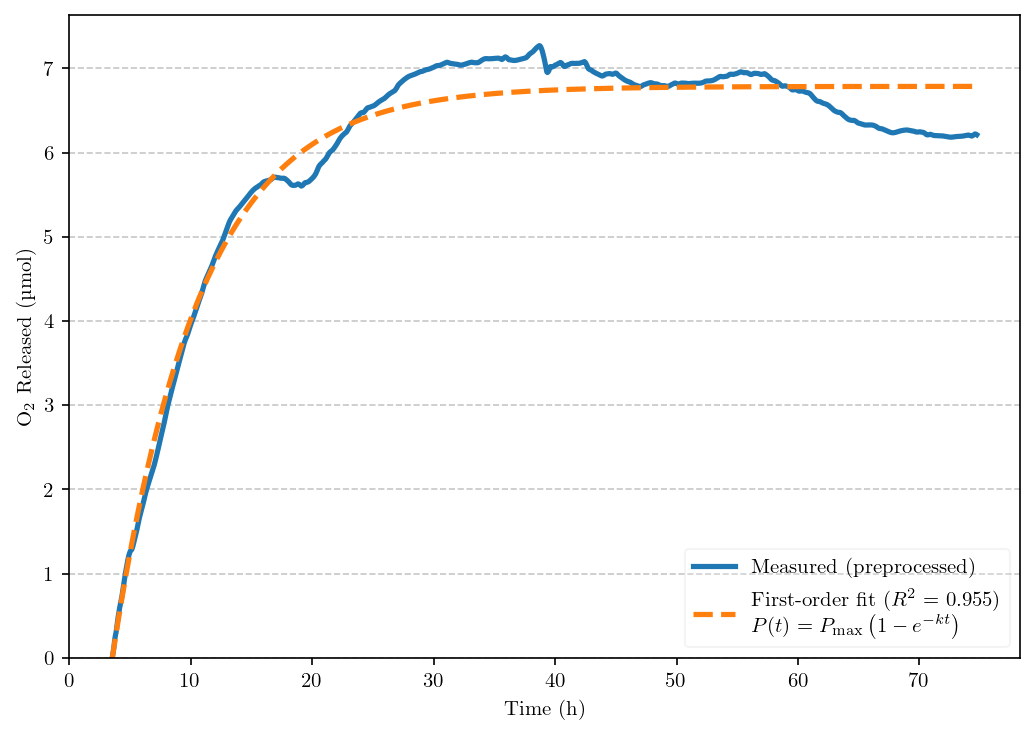

In [41]:
m33_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\37 C\Data files\M3_CROPPED.csv"
df_m33 = pd.read_csv(m33_csv)
df_m33.columns = [c.strip() for c in df_m33.columns]

# Replace these with the series/column you want to fit
ngas_m33 = df_m33["O2 Released (µmol)"].values
time_m33 = df_m33["Time (h)"].values


# --- Clean: drop NaNs/Infs and ensure strictly increasing time (if needed) ---
mask = np.isfinite(time_m33) & np.isfinite(ngas_m33)
t = np.asarray(time_m33[mask], dtype=float)
y = np.asarray(ngas_m33[mask], dtype=float)

# If times are not strictly increasing, sort them (and y accordingly)
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y = t[order], y[order]

# Optionally, shift time to start at 0 for numerical stability (doesn't change k)
t0 = t.min()
t = t - t0

# --- First-order model ---
def first_order_model(t, P_max, k):
    # P(t) = P_max * (1 - exp(-k t))
    return P_max * (1.0 - np.exp(-k * t))

# --- Fit: robust initial guesses + nonnegative bounds ---
Pmax0 = float(np.nanmax(y))
dt = max(t.max() - t.min(), 1.0)  # seconds span; guard against zero
# choose half-life ~ 30% of data span as a reasonable default
k0 = np.log(2.0) / (0.3 * dt)
k0 = max(k0, 1e-9)

popt, pcov = curve_fit(
    first_order_model, t, y,
    p0=[Pmax0 if np.isfinite(Pmax0) and Pmax0 > 0 else (y[-1] if len(y) else 1.0), k0],
    bounds=([0.0, 0.0], [np.inf, np.inf]),
    maxfev=20000
)
P_max_fit, k_fit = popt
y_fit = first_order_model(t, *popt)

# --- Metrics (first-order only) ---
def aic(n, rss, k_params):
    return n * np.log(rss / n) + 2 * k_params

def bic(n, rss, k_params):
    return n * np.log(rss / n) + k_params * np.log(n)

n = len(y)
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
aic_val = aic(n, rss, 2)  # params: P_max, k
bic_val = bic(n, rss, 2)
t_half_h = np.log(2.0) / k_fit
t_half_s = t_half_h * 3600.0

# --- Show metrics ---
metrics = pd.DataFrame({
    "Model": ["First-order"],
    "P_max (µmol)": [P_max_fit],
    "k (1/h)": [k_fit],
    "Half-Life (s)": [t_half_s],
    "Half-Life (h)": [t_half_h],
    "RMSE (µmol)": [rmse],
    "R²": [r2],
    "AIC": [aic_val],
    "BIC": [bic_val],
})
display(metrics.round(6))

# --- Plot (Plot #3 analog: data + first-order fit only) ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t + t0, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t + t0, y_fit, "--", lw=2.5,
         label=fr"First-order fit ($R^2$ = {r2:.3f})" + "\n" + r"$P(t)=P_{\max}\left(1-e^{-kt}\right)$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.xlim()
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Logistic

,Model,P_max (µmol),k (1/s),t0 (s),RMSE,R²,AIC,BIC
0,Logistic (bounded),6.722216,0.26608,9.386009,0.331529,0.9455,-565810.033038,-565778.671335


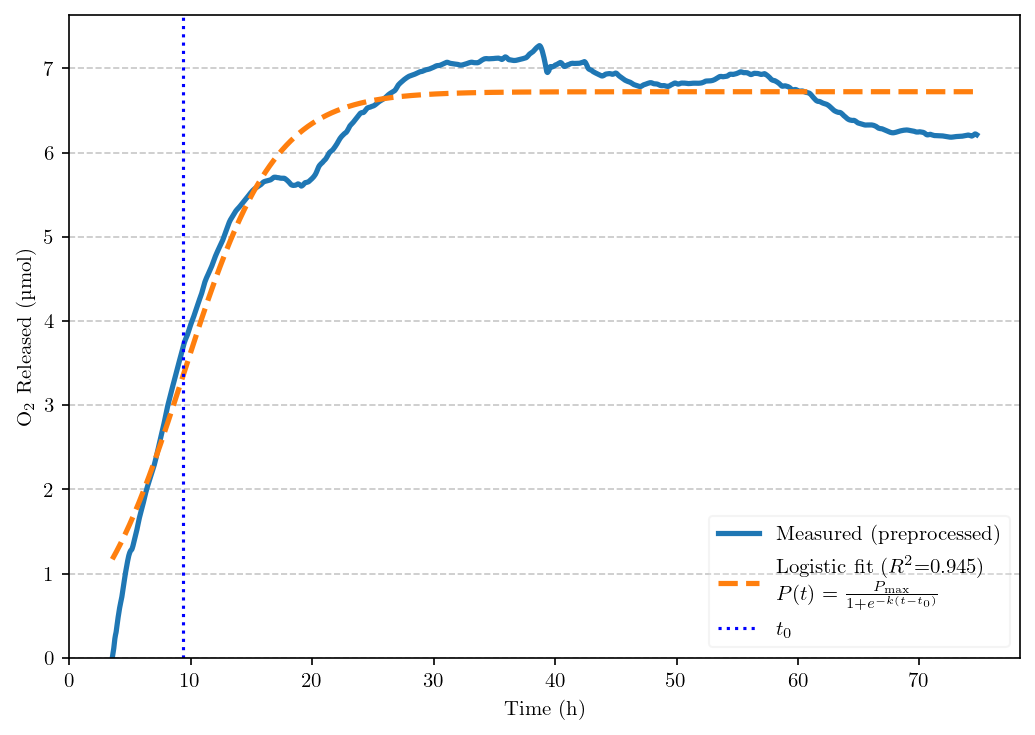

In [26]:
m33logi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\37 C\Data files\M3_CROPPED.csv"
df_m33logi = pd.read_csv(m33logi_csv)
df_m33logi.columns = [c.strip() for c in df_m33logi.columns]

# Replace these with the series/column you want to fit
ngas_m33logi = df_m33logi["O2 Released (µmol)"].values
time_m33logi = df_m33logi["Time (h)"].values

# --- Clean NaNs/Infs ---
mask = np.isfinite(time_m33logi) & np.isfinite(ngas_m33logi)
t = np.asarray(time_m33logi[mask], dtype=float)
y = np.asarray(ngas_m33logi[mask], dtype=float)

# --- Logistic model ---
def logistic_model(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))

# --- Fit function with bounds from table ---
def fit_logistic_model(time, signal):
    P_max = np.max(signal)
    # initial guess for t0 = time at ~half max
    P0_init = time[np.argmin(np.abs(signal - P_max / 2.0))]
    k_init = 1.0 / (time[-1] - time[0] + 1e-9)  # avoid div/0
    
    # bounds according to table:
    # t0: [0.8 * P0_init, 1.2 * P0_init]
    # k: [0, 1]
    # P_max: [0.8 * P_max, 1.2 * P_max]
    bounds = [
        (0.8 * P0_init, 1.2 * P0_init),
        (0.0, 1.0),
        (0.8 * P_max, 1.2 * P_max)
    ]
    
    res = minimize(
        lambda p: mean_squared_error(signal, logistic_model(time, *p)),
        [P0_init, k_init, P_max],
        bounds=bounds
    )
    popt = res.x
    fit = logistic_model(time, *popt)
    return popt, fit

# --- Run fit ---
popt, y_fit = fit_logistic_model(t, y)
t0_fit, k_fit, Pmax_fit = popt

# --- Metrics ---
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 3
bic = n * np.log(rss / n) + 3 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Logistic (bounded)"],
    "P_max (µmol)": [Pmax_fit],
    "k (1/s)": [k_fit],
    "t0 (s)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic]
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic fit ($R^2$={r2:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit, linestyle=":", color="blue", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Checking for modified bounds - Modified logistic

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC,Converged
0,Logistic (robust),6.87581,0.242534,9.639372,0.345239,0.963795,-269268.257041,-269239.010773,True


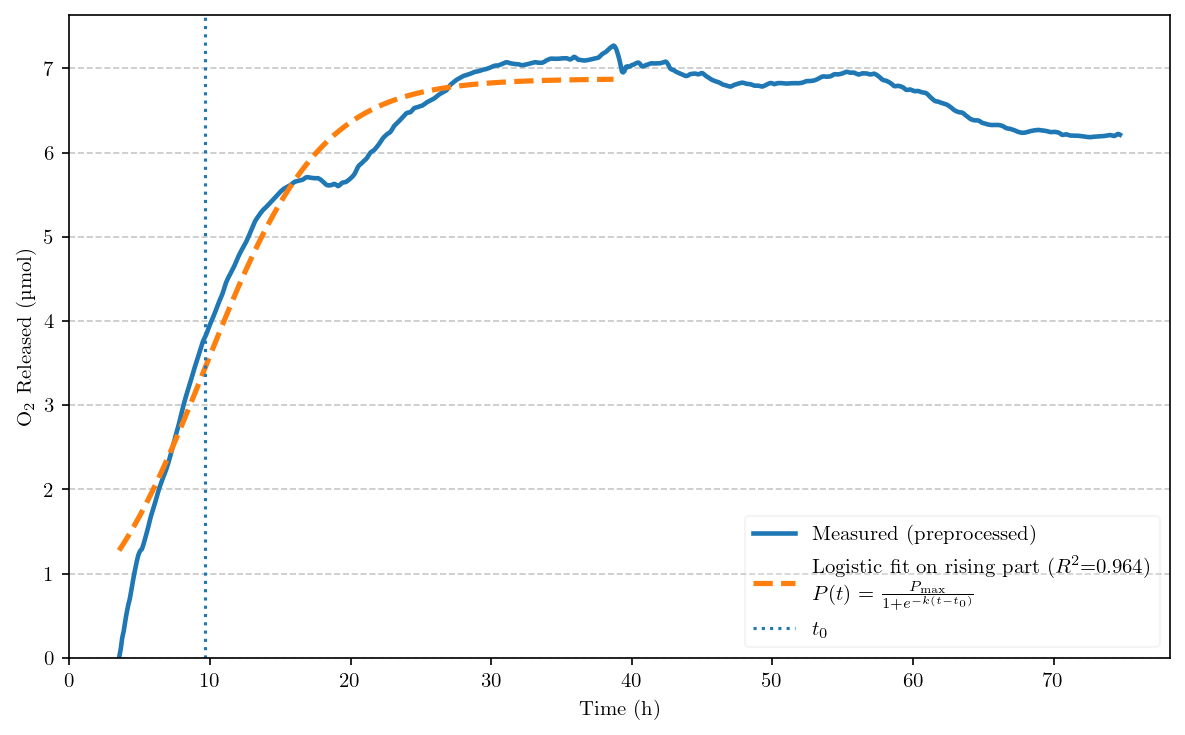

In [51]:

# --- Load CSV ---
m331logi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\37 C\Data files\M3_CROPPED.csv"
df_m331logi = pd.read_csv(m331logi_csv)
df_m331logi.columns = [c.strip() for c in df_m331logi.columns]

# Extract arrays
ngas_m331logi = df_m331logi["O2 Released (µmol)"].to_numpy(dtype=float)
time_m331logi = df_m331logi["Time (h)"].to_numpy(dtype=float) 

# --- Clean NaNs/Infs ---
mask = np.isfinite(time_m331logi) & np.isfinite(ngas_m331logi)
t_full_m331 = time_m331logi[mask]
y_full_m331 = ngas_m331logi[mask]

# --- Trim to rising part only (up to peak) ---
idx_peak = np.argmax(y_full_m331)
t_m331 = t_full_m331[: idx_peak + 1]
y_m331 = y_full_m331[: idx_peak + 1]

# --- Logistic model ---
def logistic_model_m331(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))

# --- Initial guesses ---
span_m331 = max(t_m331.max() - t_m331.min(), 1e-6)
Pmax0_m331 = np.quantile(y_m331, 0.98)

# Smooth only for slope estimation
win = max(5, int(0.03 * len(y_m331)))
if win % 2 == 0:
    win += 1
y_smooth_m331 = pd.Series(y_m331).rolling(window=win, center=True, min_periods=1).mean().to_numpy()
dy_dt_m331 = np.gradient(y_smooth_m331, t_m331)
i_inflect_m331 = int(np.argmax(dy_dt_m331))
t0_init_m331 = float(t_m331[i_inflect_m331])
slope_max_m331 = float(max(dy_dt_m331[i_inflect_m331], 1e-12))

k_init_m331 = float(4.0 * slope_max_m331 / max(Pmax0_m331, 1e-9))
k_init_m331 = np.clip(k_init_m331, 1e-6, 10.0 / span_m331)

# --- Bounds ---
bounds_m331 = [
    (t_m331.min(), t_m331.max()), 
    (1e-6, 10.0 / span_m331), 
    (0.5 * Pmax0_m331, 2.0 * max(y_m331))
]

# --- Fit ---
def fit_logistic_model_m331(time, signal):
    def obj(p):
        return mean_squared_error(signal, logistic_model_m331(time, *p))
    x0 = np.array([t0_init_m331, k_init_m331, Pmax0_m331], dtype=float)
    res = minimize(obj, x0, bounds=bounds_m331, method="L-BFGS-B")
    if not res.success:
        alt_x0 = np.array([np.median(time), 1.0 / span_m331, np.max(signal)], dtype=float)
        res = minimize(obj, alt_x0, bounds=bounds_m331, method="L-BFGS-B")
    popt = res.x
    fit = logistic_model_m331(time, *popt)
    return popt, fit, res

popt_m331, y_fit_m331, res_m331 = fit_logistic_model_m331(t_m331, y_m331)
t0_fit_m331, k_fit_m331, Pmax_fit_m331 = popt_m331

# --- Metrics ---
rss_m331 = np.sum((y_m331 - y_fit_m331) ** 2)
rmse_m331 = np.sqrt(mean_squared_error(y_m331, y_fit_m331))
r2_m331 = r2_score(y_m331, y_fit_m331)
n_m331 = len(y_m331)
aic_m331 = n_m331 * np.log(rss_m331 / n_m331 + 1e-12) + 2 * 3
bic_m331 = n_m331 * np.log(rss_m331 / n_m331 + 1e-12) + 3 * np.log(max(n_m331, 2))

metrics_m331 = pd.DataFrame({
    "Model": ["Logistic (robust)"],
    "P_max (µmol)": [Pmax_fit_m331],
    "k (1/h)": [k_fit_m331],
    "t0 (h)": [t0_fit_m331],
    "RMSE": [rmse_m331],
    "R²": [r2_m331],
    "AIC": [aic_m331],
    "BIC": [bic_m331],
    "Converged": [bool(res_m331.success)]
})
display(metrics_m331.round(6))

# --- Plot ---
plt.figure(figsize=(8, 5), dpi=150)
plt.plot(t_full_m331, y_full_m331, label="Measured (preprocessed)", lw=2.2)
plt.plot(t_m331, y_fit_m331, "--", lw=2.5,
         label=fr"Logistic fit on rising part ($R^2$={r2_m331:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit_m331, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# Gompertz

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC
0,"Gompertz (time-located, bounded)",6.744256,0.206264,7.412916,0.303696,0.954267,-610750.591027,-610719.229324


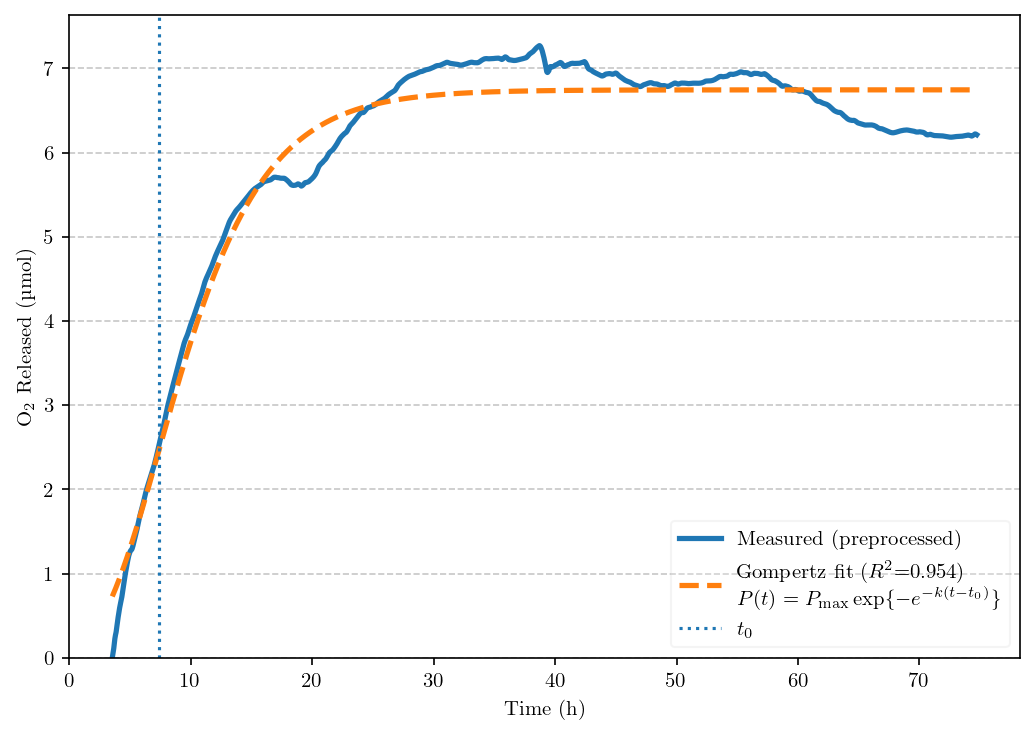

In [80]:

# m5gom_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\37 C\Data files\M3_CROPPED.csv"
# df_m5gom = pd.read_csv(m5gom_csv)
# df_m5gom.columns = [c.strip() for c in df_m5gom.columns]

# df_m5gom_pos = df_m5gom[df_m5gom["O2 Released (µmol)"] > 0].reset_index(drop=True)
# ngas_m5gom = df_m5gom_pos["O2 Released (µmol)"].to_numpy(dtype=float)
# time_m5gom = df_m5gom_pos["Time (h)"].to_numpy(dtype=float)

# # ---- Clean ----
# mask = np.isfinite(time_m5gom) & np.isfinite(ngas_m5gom)
# t_m5gom = np.asarray(time_m5gom[mask], dtype=float)
# y_m5gom = np.asarray(ngas_m5gom[mask], dtype=float)

# # Ensure increasing time
# if np.any(np.diff(t_m5gom) <= 0):
#     order = np.argsort(t_m5gom)
#     t_m5gom = t_m5gom[order]
#     y_m5gom = y_m5gom[order]

# # ---- Gompertz (time-located form) ----
# def gompertz_time_loc(t, t0, k, Pmax):
#     return Pmax * np.exp(-np.exp(-k * (t - t0)))

# # ---- Initial guesses ----
# Pmax0_m5gom = float(np.max(y_m5gom))
# t0_init_m5gom = float(t_m5gom[np.argmin(np.abs(y_m5gom - 0.5 * Pmax0_m5gom))])
# dt_m5gom = max(t_m5gom.max() - t_m5gom.min(), 1.0)  # hours
# k_init_m5gom = 1.0 / dt_m5gom

# # ---- Logistic-style bounds ----
# lower_bounds_m5gom = [0.8 * t0_init_m5gom, 0.0, 0.8 * Pmax0_m5gom]
# upper_bounds_m5gom = [1.2 * t0_init_m5gom, 1.0, 1.2 * Pmax0_m5gom]
# p0_m5gom = [t0_init_m5gom, k_init_m5gom, Pmax0_m5gom]

# # ---- Fit ----
# popt_m5gom, pcov_m5gom = curve_fit(
#     gompertz_time_loc, t_m5gom, y_m5gom,
#     p0=p0_m5gom, bounds=(lower_bounds_m5gom, upper_bounds_m5gom), maxfev=20000
# )
# t0_fit_m5gom, k_fit_m5gom, Pmax_fit_m5gom = popt_m5gom
# y_fit_m5gom = gompertz_time_loc(t_m5gom, *popt_m5gom)

# # ---- Metrics ----
# rss_m5gom = np.sum((y_m5gom - y_fit_m5gom) ** 2)
# rmse_m5gom = np.sqrt(mean_squared_error(y_m5gom, y_fit_m5gom))
# r2_m5gom = r2_score(y_m5gom, y_fit_m5gom)
# n_m5gom = len(y_m5gom)
# aic_m5gom = n_m5gom * np.log(rss_m5gom / n_m5gom) + 2 * 3
# bic_m5gom = n_m5gom * np.log(rss_m5gom / n_m5gom) + 3 * np.log(n_m5gom)

# metrics_m5gom = pd.DataFrame({
#     "Model": ["Gompertz (time-located, bounded)"],
#     "P_max (µmol)": [Pmax_fit_m5gom],
#     "k (1/h)": [k_fit_m5gom],    # hours
#     "t0 (h)": [t0_fit_m5gom],
#     "RMSE": [rmse_m5gom],
#     "R²": [r2_m5gom],
#     "AIC": [aic_m5gom],
#     "BIC": [bic_m5gom]
# })
# display(metrics_m5gom.round(6))

# # ---- Plot ----
# plt.figure(figsize=(7, 5), dpi=150)
# plt.plot(t_m5gom, y_m5gom, label="Measured (preprocessed)", lw=2.5)
# plt.plot(t_m5gom, y_fit_m5gom, "--", lw=2.5,
#          label=fr"Gompertz fit ($R^2$={r2_m5gom:.3f})" + "\n" + r"$P(t)=P_{\max}\exp\{-e^{-k(t-t_0)}\}$")
# plt.axvline(t0_fit_m5gom, linestyle=":", label=r"$t_0$")
# plt.xlabel("Time (h)")
# plt.ylabel("O$_2$ Released (µmol)")
# plt.ylim(bottom=0)
# plt.grid(axis="y", linestyle="--", alpha=0.7)
# plt.legend(loc="lower right", frameon=True, framealpha=0.2)
# plt.tight_layout()
# plt.show()


# Gompertz - different bounds

### The bounds were choosen based on research paramaters as follows:
1. t0 (inflection point) selection : 
Logistic curve: the fastest growth (inflection point) happens when the curve has reached half of its maximum.
Gompertz curve: the fastest growth happens earlier, around 35–40% of the maximum.source : https://www.pnas.org/doi/pdf/10.1073/pnas.18.1.1

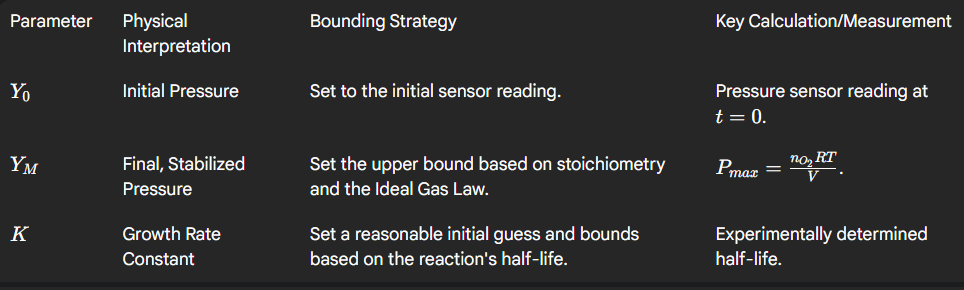

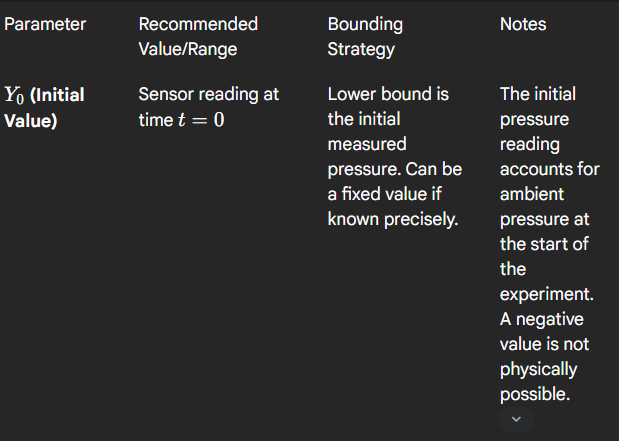
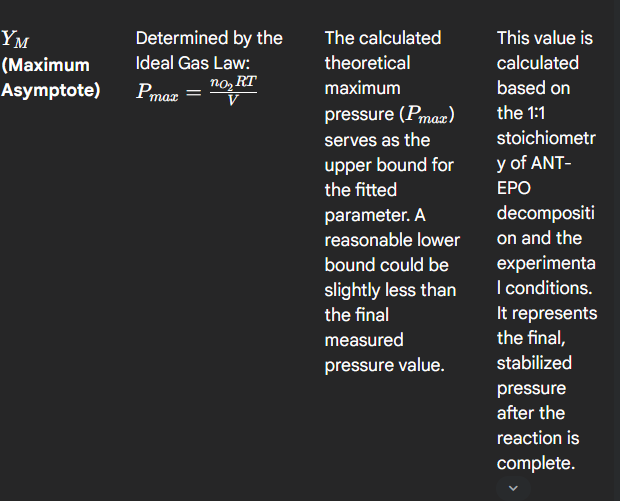
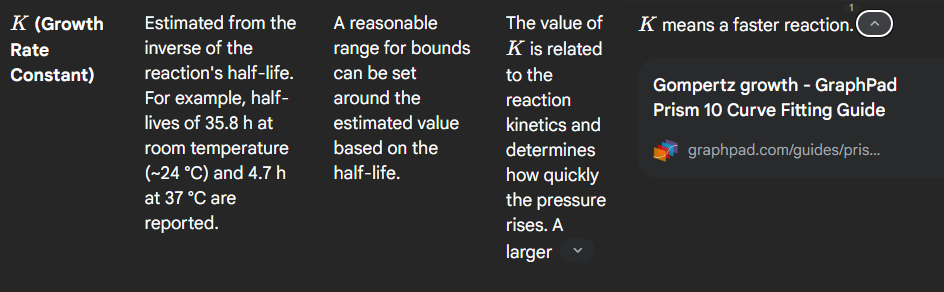

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC
0,Gompertz (Winsor-consistent t0),6.859721,0.140489,6.577168,0.381644,0.927778,-493664.767142,-493633.405439


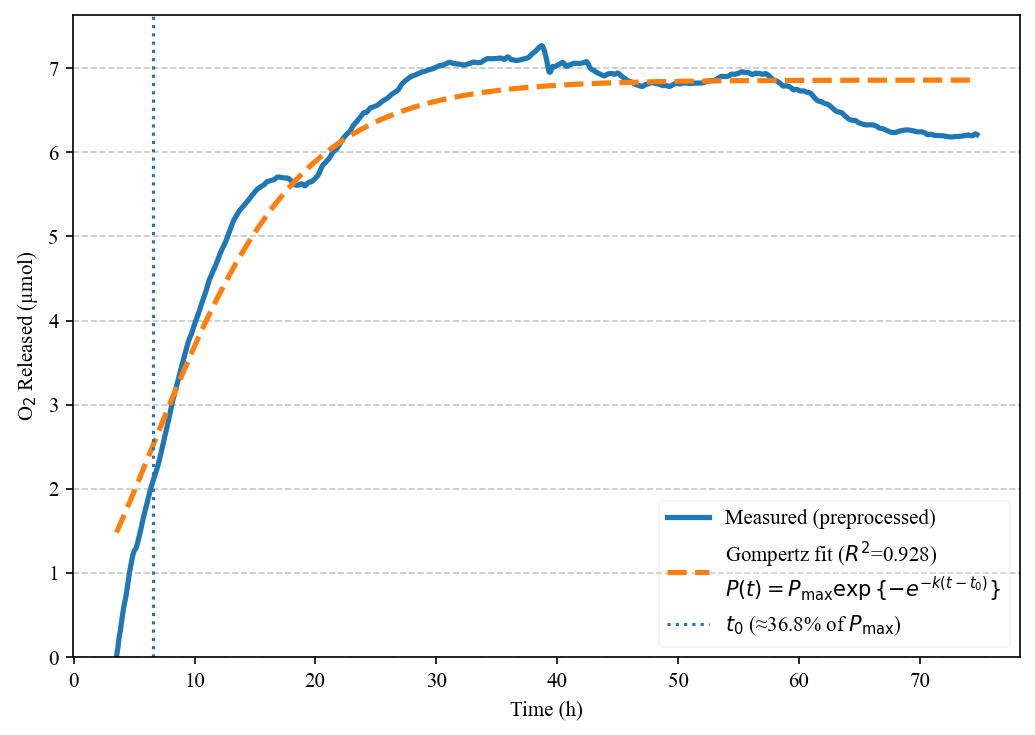

In [85]:

# import matplotlib as mpl
# mpl.rcParams["text.usetex"] = False
# # ---- Load data (hours, µmol) ----
# m5gom_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\37 C\Data files\M3_CROPPED.csv"
# df_m5gom = pd.read_csv(m5gom_csv)
# df_m5gom.columns = [c.strip() for c in df_m5gom.columns]

# df_m5gom_pos = df_m5gom[df_m5gom["O2 Released (µmol)"] > 0].reset_index(drop=True)
# y_m5gom = df_m5gom_pos["O2 Released (µmol)"].to_numpy(dtype=float)
# t_m5gom = df_m5gom_pos["Time (h)"].to_numpy(dtype=float)

# # ---- Clean & sort ----
# mask = np.isfinite(t_m5gom) & np.isfinite(y_m5gom)
# t_m5gom = t_m5gom[mask].astype(float)
# y_m5gom = y_m5gom[mask].astype(float)
# if np.any(np.diff(t_m5gom) <= 0):
#     order = np.argsort(t_m5gom)
#     t_m5gom, y_m5gom = t_m5gom[order], y_m5gom[order]

# # ---- Gompertz (time-located form): P(t) = Pmax * exp{-exp[-k (t - t0)]} ----
# def gompertz_time_loc(t, t0, k, Pmax):
#     return Pmax * np.exp(-np.exp(-k * (t - t0)))

# # ---- Winsor-consistent t0 (inflection at ~36.8% of Pmax) ----
# # robust Pmax from data
# Pobs = float(np.quantile(y_m5gom, 0.98))  # asymptote proxy from data
# # make a monotone proxy for crossing-time lookup
# yy_mono = np.maximum.accumulate(np.maximum(y_m5gom, 0))
# # time at 36.8% of Pobs (≈ inflection for Gompertz)
# target_37 = 1.0/np.e * Pobs
# target_37 = np.clip(target_37, yy_mono.min(), yy_mono.max())
# t0_init_m5gom = float(np.interp(target_37, yy_mono, t_m5gom))

# # ---- k init and bounds ----
# span = max(t_m5gom.max() - t_m5gom.min(), 1e-6)  # hours
# # slope-based k init: smooth a bit for a stable derivative
# win = max(5, int(0.03 * len(yy_mono)));  win += (win % 2 == 0)
# y_s = pd.Series(y_m5gom).rolling(win, center=True, min_periods=1).mean().to_numpy()
# dy = np.gradient(y_s, t_m5gom)
# slope_max = float(np.nanmax(dy))
# k_init_m5gom = float(np.e * slope_max / max(Pobs, 1e-9))  # from P'(t0)=k*Pmax/e
# # sanity cap by span
# k_lo, k_hi = max(1e-6, 0.25*k_init_m5gom), min(10.0/span, 4.0*k_init_m5gom)
# k_init_m5gom = np.clip(k_init_m5gom, k_lo, k_hi)

# # ---- Pmax bounds ----
# Pmax_lo, Pmax_hi = 0.9*Pobs, 1.2*Pobs

# # ---- t0 bounds around the 36.8% time ----
# t0_lo, t0_hi = 0.8*t0_init_m5gom, 1.2*t0_init_m5gom

# # ---- Pack for curve_fit ----
# p0_m5gom = [t0_init_m5gom, k_init_m5gom, Pobs]
# lower_bounds_m5gom = [t0_lo, k_lo, Pmax_lo]
# upper_bounds_m5gom = [t0_hi, k_hi, Pmax_hi]

# # ---- Fit ----
# popt_m5gom, pcov_m5gom = curve_fit(
#     gompertz_time_loc, t_m5gom, y_m5gom,
#     p0=p0_m5gom, bounds=(lower_bounds_m5gom, upper_bounds_m5gom), maxfev=20000
# )
# t0_fit_m5gom, k_fit_m5gom, Pmax_fit_m5gom = popt_m5gom
# y_fit_m5gom = gompertz_time_loc(t_m5gom, *popt_m5gom)

# # ---- Metrics ----
# rss = np.sum((y_m5gom - y_fit_m5gom) ** 2)
# rmse = np.sqrt(mean_squared_error(y_m5gom, y_fit_m5gom))
# r2 = r2_score(y_m5gom, y_fit_m5gom)
# n = len(y_m5gom)
# aic = n * np.log(rss / n + 1e-12) + 2 * 3
# bic = n * np.log(rss / n + 1e-12) + 3 * np.log(max(n, 2))

# metrics = pd.DataFrame({
#     "Model": ["Gompertz (Winsor-consistent t0)"],
#     "P_max (µmol)": [Pmax_fit_m5gom],
#     "k (1/h)": [k_fit_m5gom],
#     "t0 (h)": [t0_fit_m5gom],     # ~36.8% of Pmax
#     "RMSE": [rmse],
#     "R²": [r2],
#     "AIC": [aic],
#     "BIC": [bic]
# })
# display(metrics.round(6))

# # ---- Plot ----
# plt.figure(figsize=(7, 5), dpi=150)
# plt.plot(t_m5gom, y_m5gom, label="Measured (preprocessed)", lw=2.5)
# plt.plot(t_m5gom, y_fit_m5gom, "--", lw=2.5,
#          label=fr"Gompertz fit ($R^2$={r2:.3f})" + "\n" + r"$P(t)=P_{\max}\exp\{-e^{-k(t-t_0)}\}$")
# plt.axvline(t0_fit_m5gom, linestyle=":", label=r"$t_0$ (≈36.8% of $P_{\max}$)")
# plt.xlabel("Time (h)")
# plt.ylabel("O$_2$ Released (µmol)")
# plt.ylim(bottom=0)
# plt.grid(axis="y", linestyle="--", alpha=0.7)
# plt.legend(loc="lower right", frameon=True, framealpha=0.2)
# plt.tight_layout()
# plt.show()


# For the below code:

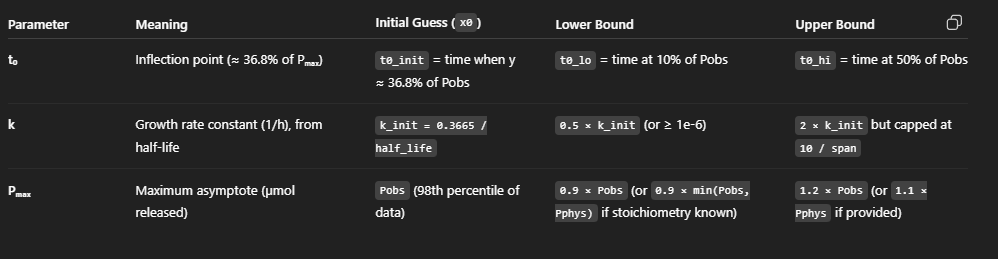

,Model,P_max (µmol),k (1/h),t0 (h),Half-life used (h),RMSE,R²,AIC,BIC
0,"Gompertz (k from half-life, 37 °C)",6.859722,0.140489,6.577186,4.7,0.381644,0.927778,-493664.767153,-493633.40545


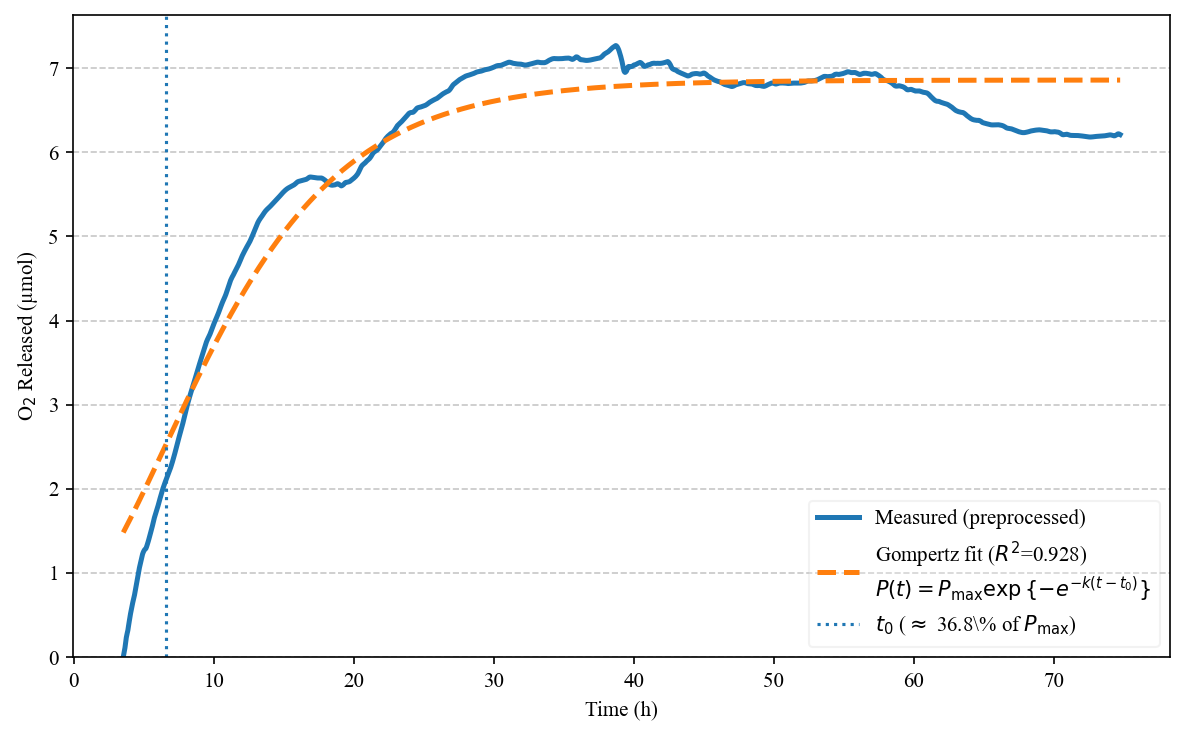

In [86]:
# --- Full cell: Gompertz fit with k tied to half-life (37 °C) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score

# ------------------ USER INPUTS ------------------
csv_path = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\37 C\Data files\M3_CROPPED.csv"
time_col = "Time (h)"                 # time in HOURS
signal_col = "O2 Released (µmol)"     # response in µmol
keep_positive_only = True             # drop rows with y <= 0 (optional)

# Half-life at 37 °C (hours). If you have a different value, change it here.
half_life_h = 4.7                     # example from your note

# Optional stoichiometric maximum (µmol) to physically cap Pmax.
# If you know n_O2 (µmol), put it here; else set to None.
Pphys_umol = None   # e.g., 7.2   # <-- set to µmol units if known; else None
# ------------------------------------------------

# 1) Load & clean
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]
y_raw = df[signal_col].to_numpy(dtype=float)
t_raw = df[time_col].to_numpy(dtype=float)

if keep_positive_only:
    mpos = y_raw > 0
    t_raw, y_raw = t_raw[mpos], y_raw[mpos]

mask = np.isfinite(t_raw) & np.isfinite(y_raw)
t = t_raw[mask].astype(float)
y = y_raw[mask].astype(float)

# Ensure strictly increasing time (sort if needed)
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y = t[order], y[order]

# 2) Model: Gompertz (time-located form)
#    P(t) = Pmax * exp{-exp[-k (t - t0)]}
def gompertz_time_loc(t, t0, k, Pmax):
    return Pmax * np.exp(-np.exp(-k * (t - t0)))

# 3) Helper: bounds and initial guesses
def build_bounds_and_x0_gompertz(t, y, half_life_h, Pphys=None):
    """
    Builds physically informed bounds and initial guess for (t0, k, Pmax).
    - t0: centered at ~36.8% of Pmax (Winsor), bounded to the early rise [10%, 50%].
    - k:  set from half-life via Gompertz identity: k = 0.3665129 / half_life_h,
          then bounded by [0.5*k_init, 2*k_init] and intersected with span sanity cap.
    - Pmax: bounded using observed 98th percentile and optional stoichiometric cap Pphys (µmol).
    """
    t = np.asarray(t, float); y = np.asarray(y, float)
    Pobs = float(np.quantile(y, 0.98))  # robust asymptote proxy

    # Pmax bounds (same units as y)
    if Pphys is not None and np.isfinite(Pphys) and Pphys > 0:
        Pmax_lo = 0.9 * min(Pphys, Pobs)
        Pmax_hi = 1.1 * Pphys
    else:
        Pmax_lo = 0.9 * Pobs
        Pmax_hi = 1.2 * Pobs

    # Monotone proxy to find crossing times
    ord_ = np.argsort(t)
    tt, yy = t[ord_], y[ord_]
    yy_mono = np.maximum.accumulate(np.maximum(yy, 0))

    # crossing time helper
    def Tfrac(frac):
        target = frac * Pobs
        target = np.clip(target, yy_mono.min(), yy_mono.max())
        return float(np.interp(target, yy_mono, tt))

    T10, T37, T50 = Tfrac(0.10), Tfrac(1/np.e), Tfrac(0.50)

    # t0 bounds: early part of the rise
    t0_lo = max(tt.min(), T10)
    t0_hi = min(T50, tt.max())
    if not np.isfinite(t0_lo) or not np.isfinite(t0_hi) or t0_hi <= t0_lo:
        span = max(tt.max() - tt.min(), 1e-6)
        pad = 0.1 * span
        t0_lo, t0_hi = tt.min() + 0.2*pad, tt.max() - 0.2*pad
    t0_init = float(np.clip(T37, t0_lo, t0_hi))

    # k from half-life at 37 °C:
    # Gompertz identity: t50 - t0 = 0.3665129 / k  =>  k = 0.3665129 / half_life_h
    k_init = float(0.36651292 / max(half_life_h, 1e-9))

    # sanity cap by time span and give a reasonable bracket around k_init
    span = max(tt.max() - tt.min(), 1e-6)
    k_lo = max(1e-6, 0.5 * k_init)
    k_hi = min(10.0 / span, 2.0 * k_init)
    if k_hi <= k_lo:  # fall back if pathological
        k_lo, k_hi = 1e-6, min(10.0 / span, max(2e-6, 4.0 * k_init))
    k_init = float(np.clip(k_init, k_lo, k_hi))

    # final Pmax init at Pobs (clipped into bounds)
    Pmax_init = float(np.clip(Pobs, Pmax_lo, Pmax_hi))

    lower = [t0_lo, k_lo, Pmax_lo]
    upper = [t0_hi, k_hi, Pmax_hi]
    x0    = [t0_init, k_init, Pmax_init]
    return (lower, upper, x0)

lower, upper, x0 = build_bounds_and_x0_gompertz(t, y, half_life_h=half_life_h, Pphys=Pphys_umol)

# 4) Fit
popt, pcov = curve_fit(
    gompertz_time_loc, t, y,
    p0=x0, bounds=(lower, upper), maxfev=20000
)
t0_fit, k_fit, Pmax_fit = popt
y_fit = gompertz_time_loc(t, *popt)

# 5) Metrics
rss = np.sum((y - y_fit) ** 2)
rmse = float(np.sqrt(mean_squared_error(y, y_fit)))
r2 = float(r2_score(y, y_fit))
n = len(y)
aic = float(n * np.log(rss / n + 1e-12) + 2 * 3)
bic = float(n * np.log(rss / n + 1e-12) + 3 * np.log(max(n, 2)))

metrics = pd.DataFrame({
    "Model": ["Gompertz (k from half-life, 37 °C)"],
    "P_max (µmol)": [Pmax_fit],
    "k (1/h)": [k_fit],
    "t0 (h)": [t0_fit],                 # ~36.8% of Pmax
    "Half-life used (h)": [half_life_h],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic]
})
display(metrics.round(6))

# 6) Plot
import matplotlib as mpl
mpl.rcParams["text.usetex"] = False   # avoid LaTeX issues with unicode

plt.figure(figsize=(8, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.4)
plt.plot(t, y_fit, "--", lw=2.4,
         label=fr"Gompertz fit ($R^2$={r2:.3f})" + "\n" + r"$P(t)=P_{\max}\exp\{-e^{-k(t-t_0)}\}$")
plt.axvline(t0_fit, linestyle=":", label=r"$t_0$ ($\approx$ 36.8\% of $P_{\max}$)")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.25)
plt.tight_layout()
plt.show()


# Final observation and analysis:


1. If the pressure rise is rapid and appears to be linear, a first-order kinetic model should be considered, especially if the experiment was conducted at a higher temperature (e.g., 37 °C).   

2. If the data shows a symmetric sigmoidal curve with an inflection point approximately at the half-way point of the final pressure, a logistic model is the most appropriate choice, as was found for the ANT-EPO system at room temperature.   

3. If the data presents an asymmetric sigmoidal curve with an inflection point occurring early in the reaction (e.g., at 35−40% of the final pressure), then the Gompertz model is the most suitable option, as it is specifically designed to capture this type of behavior.   

